[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reinhart-group/generative-copolymer-workshop/blob/main/day3/09_explainability.ipynb)

# Day 3, Afternoon: Inverse Design and Explanations

**Today's topics**
* Direct inverse design with a conditional VAE and an autoregressive decoder
* Why explainability matters in scientific ML
* Attribution by gradients and saliency maps
* Perturbation, counterfactuals, and limitations
* From attribution to testable design rules
* The pipeline as a reusable template

This morning used search to propose and validate candidates. This afternoon generates sequences
directly for a desired morphology and attributes the surrogate score to sequence positions.
The surrogate $f$ is differentiable end to end.

In [ ]:
#@title  ⚙️  Setup — build the workshop workspace (Colab). { display-mode: "form" }
# The "Open in Colab" badge loads ONLY this .ipynb into a bare VM at /content, so the
# directory layout this notebook reads by relative path -- ../data (derived tables) and
# ../models (the trained surrogate) -- does not exist yet. We do NOT clone the repo: every
# data and model artifact is published in the Zenodo bundle (concept DOI 10.5281/zenodo.21382941,
# which always resolves to the latest version),
# which is public and sha256-verified, and the helper code is spliced into this notebook.
# So this cell just creates the workspace and steps into the day directory; the
# `ensure_bundle(...)` calls further down fetch the actual data into ../data on first use.
#
# Idempotent, and a no-op if you are already running from a repo checkout (instructors).
import os, sys

WORKSPACE = os.environ.get('CDSE_WORKSPACE', '/content/cdse-workshop')
DAY_DIR = 'day3'

if os.path.isdir('../data') and os.path.isdir('../campaign'):
    print(f'✅ already inside a workshop checkout — cwd={os.getcwd()}')
else:
    for sub in ('data', 'models', DAY_DIR):
        os.makedirs(os.path.join(WORKSPACE, sub), exist_ok=True)
    os.chdir(os.path.join(WORKSPACE, DAY_DIR))
    print(f'✅ workspace ready — cwd={os.getcwd()}')
    print('   ../data and ../models will be filled from Zenodo by the ensure_bundle() calls below.')

## Where this comes from

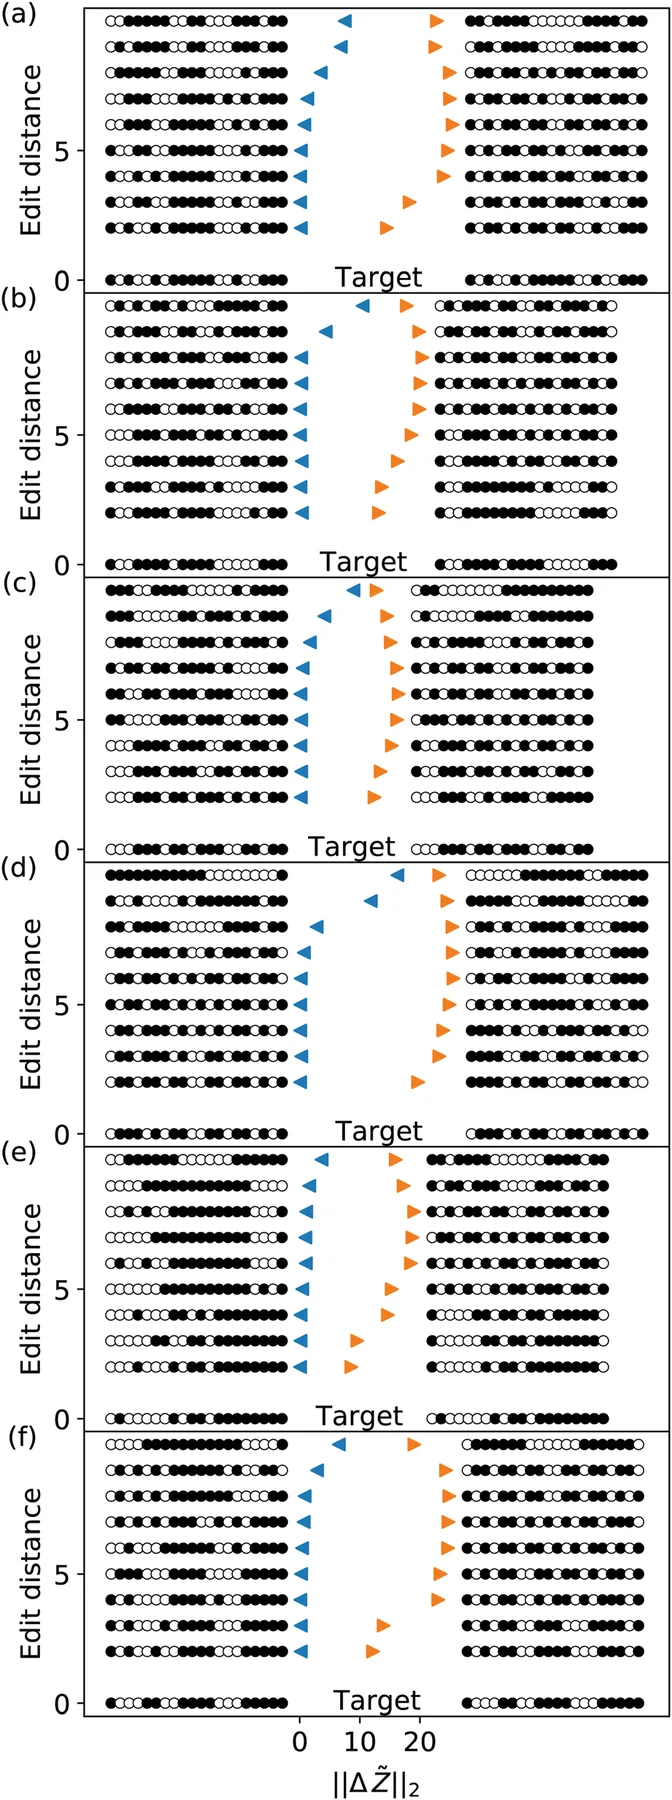

*Fig. 11. Bhattacharya, Kleeblatt, Statt & Reinhart, Soft Matter **18**, 5037 (2022). [doi.org/10.1039/d2sm00452f](https://doi.org/10.1039/d2sm00452f)*

This figure asks what happens to the model's prediction when you edit a sequence: each panel
fixes a target, then finds the edits that move the predicted morphology least (blue) and most
(orange) at a given edit distance. Section 4 reproduces this contrastive analysis. The paper searched
63,090 fixed-composition sequences; you'll use single flips and small motif-matched edit sets,
coarser but directly inspectable.

In [ ]:
# All dependencies pre-installed on Colab
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [ ]:
#@title  ⚙️  data_bootstrap — verify data/master64 & data/exhaustive10 artifacts are present. You can ignore this cell. { display-mode: "form" }
#
# A fresh checkout only ships the small derived tables in data/master64/ (tracked in git,
# see data/master64/README.md) -- the large binaries (pca.joblib, atlas*.png, _images/) and
# the full exhaustive10 library are regenerated or fetched separately and are NOT guaranteed
# to be present. Rather than let a missing file surface as a cryptic pandas/joblib traceback
# many cells later, this module checks up front and fails with an actionable message.
#
# This is deliberately a *data*-layer check, not a model one: models/gru_bundle.joblib has
# its own, stricter provenance binding (sha256 of pca.joblib + sequence_z_targets.csv recorded
# inside the bundle, checked at load time -- see notebook 06, "Provenance binding, not just a
# file-exists cache"). That check catches "this trained model doesn't match today's data" and
# is not duplicated here. This module only answers the earlier question: are the required data
# files even on disk, and do the git-tracked ones match what's checked in (data/master64/checksums.json)?

import hashlib
import json
import os
import shutil
import tarfile
import urllib.request


def sha256_of_file(path, chunk_size=1 << 20):
    """Hash a file's bytes. Same convention notebook 06 uses to bind gru_bundle.joblib
    to the pca.joblib / sequence_z_targets.csv it was trained against."""
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()


def require_data_artifacts(base_dir, filenames, checksums_path=None, regen_hint=''):
    """Verify each of `filenames` exists under `base_dir`, and -- if `checksums_path` points
    at a JSON {filename: sha256} manifest that has an entry for it -- that its sha256 matches.

    Call this once, right after the relevant `*_DIR` is set, before any of `filenames` is
    read. Raises RuntimeError with every missing/mismatched file listed together (not just
    the first one hit) and a regeneration hint, instead of letting the notebook die on
    whichever read happens to come first.
    """
    checksums = {}
    if checksums_path and os.path.exists(checksums_path):
        with open(checksums_path) as f:
            checksums = json.load(f)

    missing, mismatched = [], []
    for name in filenames:
        path = os.path.join(base_dir, name)
        if not os.path.exists(path):
            missing.append(path)
            continue
        expected = checksums.get(name)
        if expected is not None:
            actual = sha256_of_file(path)
            if actual != expected:
                mismatched.append((path, expected, actual))

    if not missing and not mismatched:
        return

    parts = []
    if missing:
        listed = '\n  '.join(missing)
        parts.append(f'Missing required data artifact(s):\n  {listed}')
    if mismatched:
        listed = '\n  '.join(
            f'{p}\n    expected sha256 {exp[:12]}…, found {act[:12]}… '
            f'(local file does not match data/master64/checksums.json)'
            for p, exp, act in mismatched
        )
        parts.append(f'Data artifact(s) present but do NOT match the checked-in checksums:\n  {listed}')
    if regen_hint:
        parts.append(regen_hint)
    raise RuntimeError('\n\n'.join(parts))


# ── Bundle fetch shim (data/_bundles/*.tar.gz) ──────────────────────────────
#
# `data/_bundles/` holds gzip-tar archives packaging the subset of `data/` a
# fresh checkout doesn't ship (large binaries: images, GSDs, the exhaustive10
# library, and notebook 06's trained model artifacts). Each archive's relative
# paths match their layout under `data/`/`models/` exactly (e.g.
# `master64/pca.joblib`, `models/gru_predictor.pt`), so extracting one directly
# into `data_dir` reproduces the paths every notebook already expects -- no
# notebook-side path changes needed once a bundle is fetched. See
# `data/_bundles/manifest.json` for the authoritative sha256/size of every
# archive; this module's `ensure_bundle` reads that same file.
#
# Hosted on Zenodo, concept DOI 10.5281/zenodo.21382941, which always resolves to the
# latest version. ZENODO_RECORD above pins a specific version record on purpose, so a
# checkout keeps fetching the exact archives it was tested against: currently v2
# (record 21856114), which adds the random-walk-init arm to v1's (21382942) lattice-init
# data. Zenodo carries every prior version's files forward, so the v1 archive names keep
# resolving against the newer record.
# Wired up and live: within Day 3, notebooks 07, 08 and 09 each call
# `ensure_bundle('core')` followed by `reconcile_bundle_models()` before loading the
# trained GRU surrogate.
#
# Kept identical to day1/day2's copies of this shim (same URLs) -- duplicated
# per-day rather than cross-imported, matching this repo's existing convention
# of a self-contained data_bootstrap.py per day. Only the day-specific loaders and
# helpers differ between the three copies (`reconcile_bundle_models()` here,
# `fetch_gsd_for_sequence` in day1, the exhaustive10 .npz loaders in day2).

ZENODO_RECORD = 'https://zenodo.org/api/records/21856114/files'

BUNDLE_URLS = {
    'core': f'{ZENODO_RECORD}/core.tar.gz/content',
    'full_images': f'{ZENODO_RECORD}/full_images.tar.gz/content',
    'gsd_shard_01': f'{ZENODO_RECORD}/gsd_shard_01.tar.gz/content',
    'gsd_shard_02': f'{ZENODO_RECORD}/gsd_shard_02.tar.gz/content',
    'gsd_shard_03': f'{ZENODO_RECORD}/gsd_shard_03.tar.gz/content',
    'gsd_shard_04': f'{ZENODO_RECORD}/gsd_shard_04.tar.gz/content',
    'gsd_shard_05': f'{ZENODO_RECORD}/gsd_shard_05.tar.gz/content',
    'gsd_shard_06': f'{ZENODO_RECORD}/gsd_shard_06.tar.gz/content',
    'gsd_shard_07': f'{ZENODO_RECORD}/gsd_shard_07.tar.gz/content',
    'gsd_shard_08': f'{ZENODO_RECORD}/gsd_shard_08.tar.gz/content',
    'gsd_shard_09': f'{ZENODO_RECORD}/gsd_shard_09.tar.gz/content',
    'gsd_shard_10': f'{ZENODO_RECORD}/gsd_shard_10.tar.gz/content',
    'gsd_shard_11': f'{ZENODO_RECORD}/gsd_shard_11.tar.gz/content',
    'gsd_shard_12': f'{ZENODO_RECORD}/gsd_shard_12.tar.gz/content',
    'gsd_shard_13': f'{ZENODO_RECORD}/gsd_shard_13.tar.gz/content',
    'gsd_shard_14': f'{ZENODO_RECORD}/gsd_shard_14.tar.gz/content',
    'gsd_shard_15': f'{ZENODO_RECORD}/gsd_shard_15.tar.gz/content',
    'gsd_shard_16': f'{ZENODO_RECORD}/gsd_shard_16.tar.gz/content',
    'rwinit_core': f'{ZENODO_RECORD}/rwinit_core.tar.gz/content',
    'rwinit_gsd_shard_01': f'{ZENODO_RECORD}/rwinit_gsd_shard_01.tar.gz/content',
    'rwinit_gsd_shard_02': f'{ZENODO_RECORD}/rwinit_gsd_shard_02.tar.gz/content',
    'rwinit_gsd_shard_03': f'{ZENODO_RECORD}/rwinit_gsd_shard_03.tar.gz/content',
    'rwinit_gsd_shard_04': f'{ZENODO_RECORD}/rwinit_gsd_shard_04.tar.gz/content',
    'rwinit_gsd_shard_05': f'{ZENODO_RECORD}/rwinit_gsd_shard_05.tar.gz/content',
    'rwinit_gsd_shard_06': f'{ZENODO_RECORD}/rwinit_gsd_shard_06.tar.gz/content',
    'rwinit_gsd_shard_07': f'{ZENODO_RECORD}/rwinit_gsd_shard_07.tar.gz/content',
    'rwinit_gsd_shard_08': f'{ZENODO_RECORD}/rwinit_gsd_shard_08.tar.gz/content',
    'rwinit_gsd_shard_09': f'{ZENODO_RECORD}/rwinit_gsd_shard_09.tar.gz/content',
    'rwinit_gsd_shard_10': f'{ZENODO_RECORD}/rwinit_gsd_shard_10.tar.gz/content',
    'rwinit_gsd_shard_11': f'{ZENODO_RECORD}/rwinit_gsd_shard_11.tar.gz/content',
    'rwinit_gsd_shard_12': f'{ZENODO_RECORD}/rwinit_gsd_shard_12.tar.gz/content',
    'rwinit_gsd_shard_13': f'{ZENODO_RECORD}/rwinit_gsd_shard_13.tar.gz/content',
    'rwinit_gsd_shard_14': f'{ZENODO_RECORD}/rwinit_gsd_shard_14.tar.gz/content',
    'rwinit_gsd_shard_15': f'{ZENODO_RECORD}/rwinit_gsd_shard_15.tar.gz/content',
    'rwinit_gsd_shard_16': f'{ZENODO_RECORD}/rwinit_gsd_shard_16.tar.gz/content',
    'rwinit_images': f'{ZENODO_RECORD}/rwinit_images.tar.gz/content',
}


# Embedded copy of data/_bundles/manifest.json (sha256 + size only -- the two fields
# ensure_bundle verifies). The manifest normally ships in the repo, but a Colab student
# opens a bare .ipynb with no repo around it, so a repo-only manifest would make every
# ensure_bundle() call fail before it ever reached Zenodo. The on-disk file still wins
# when present (instructors regenerating bundles); this is the fallback.
EMBEDDED_MANIFEST = {
    "core.tar.gz": {
        "sha256": "aa8e566e323d83a3cf5bd9f8d66af97597176bfa556497536a2313d9257a86e8",
        "size_bytes": 75795762
    },
    "full_images.tar.gz": {
        "sha256": "f5a3be425507b54446b6b8b432432e612637a26105cacd94ba04f46f9fcd9f98",
        "size_bytes": 85260688
    },
    "gsd_shard_01.tar.gz": {
        "sha256": "5ffe93ba71d42eed5abeedcc6e4dd9e0bc8d160e3d2f134cea06285b9781d590",
        "size_bytes": 54428843
    },
    "gsd_shard_02.tar.gz": {
        "sha256": "541573a1d8176f89f4f838698bee261a24818c93967b0c969e8d295ba87805eb",
        "size_bytes": 54515060
    },
    "gsd_shard_03.tar.gz": {
        "sha256": "5fd7ed9efce62468b73e633b3dd56de13ca5d5e83c87222b5d0f30eab3cd874d",
        "size_bytes": 54500993
    },
    "gsd_shard_04.tar.gz": {
        "sha256": "7c2b102d648d918bb5f702137c925533c32c22070d5a20075b536f795251524c",
        "size_bytes": 54501617
    },
    "gsd_shard_05.tar.gz": {
        "sha256": "f8da9b7c5e515e5a61b6b91d390a65a95b85aab48a6b31c6a2f5bb786306e1ee",
        "size_bytes": 54486771
    },
    "gsd_shard_06.tar.gz": {
        "sha256": "40d94a51cf1c4e59e06998e438b40a67ee52f7447e4e8089e6c1ba3efe707e92",
        "size_bytes": 54503309
    },
    "gsd_shard_07.tar.gz": {
        "sha256": "3a1a633d093e8df54062868bca408b2ea81d3121b6e18e151fabd620c9908227",
        "size_bytes": 54545175
    },
    "gsd_shard_08.tar.gz": {
        "sha256": "6edd4e9b39081c82847da3e8f5c048ba07b774513514bb293d8fc43c5f59fe5c",
        "size_bytes": 54553660
    },
    "gsd_shard_09.tar.gz": {
        "sha256": "ddebef1f8420db4e1646013640450f06c50883cc8220e6fe47847dbc816bab48",
        "size_bytes": 54529750
    },
    "gsd_shard_10.tar.gz": {
        "sha256": "8f92a0c7261217e282f16370b1483ab72c7627d452369a302d4a1cb553fd2101",
        "size_bytes": 54576422
    },
    "gsd_shard_11.tar.gz": {
        "sha256": "b4f713683ce4c9a9c7338a973162c33e26fae4abd3198ce51a232d41ab7d8213",
        "size_bytes": 54614646
    },
    "gsd_shard_12.tar.gz": {
        "sha256": "c6d9199bb584dec3dab80518ce52e591d90dcbd55d4565a17bfd899cec1cde90",
        "size_bytes": 54558926
    },
    "gsd_shard_13.tar.gz": {
        "sha256": "e40332193347a5532fc560189608b46617fc277333be14ae6a1a73b4b619ea27",
        "size_bytes": 54515392
    },
    "gsd_shard_14.tar.gz": {
        "sha256": "cd88ff742f800ba576088cb680d0d61dd7c9c63090a77c25deeddf54d728f748",
        "size_bytes": 54556976
    },
    "gsd_shard_15.tar.gz": {
        "sha256": "d4eea2c8040774d777ac384b55c5a8e473e413619c8b799690121986dcce0c61",
        "size_bytes": 54553791
    },
    "gsd_shard_16.tar.gz": {
        "sha256": "403bf562e8325f34d4b04dff699d3cc35a9b4e7dda231e01a5fdb836a9b788d1",
        "size_bytes": 54546362
    },
    "rwinit_core.tar.gz": {
        "sha256": "11cf1dc26ee026894c3be5e845d3999c1f92d43db05b2cd6eeaae92d319f1d34",
        "size_bytes": 7205225
    },
    "rwinit_gsd_shard_01.tar.gz": {
        "sha256": "064e6bd3fa80355f869f0bc29709c9df7ee5957c23e75d0e1507f405de3f7b55",
        "size_bytes": 57106441
    },
    "rwinit_gsd_shard_02.tar.gz": {
        "sha256": "41797e4e0ca818f6f6cee27eef92eecd41fa4bd0bd9d005578feae96c91bb9ac",
        "size_bytes": 57129517
    },
    "rwinit_gsd_shard_03.tar.gz": {
        "sha256": "d78bcb538e3fce2e05cf2dc2a835fd38f05a4073865e67398bec873bfd9941a5",
        "size_bytes": 57072047
    },
    "rwinit_gsd_shard_04.tar.gz": {
        "sha256": "23c24f3dbc2df1d9cdaba442dc88c6beb4c023285ee058cbf4adcaeb8964e603",
        "size_bytes": 57081717
    },
    "rwinit_gsd_shard_05.tar.gz": {
        "sha256": "2dae4ba886506429b40f82896be904a756b3f4bbb0b817792cdd7fb64e54820f",
        "size_bytes": 57089702
    },
    "rwinit_gsd_shard_06.tar.gz": {
        "sha256": "cf175506cbce294a5204abf811db5ca5f74c21d90af1516a30d08e6c188b53e3",
        "size_bytes": 57098922
    },
    "rwinit_gsd_shard_07.tar.gz": {
        "sha256": "d19cab8e719aa1fe4167a7982c3fa9f8acadb776711eb4aa2dba2840fcdd27d0",
        "size_bytes": 57116603
    },
    "rwinit_gsd_shard_08.tar.gz": {
        "sha256": "55ac119a7e3159659151abe48811389568030095af779b9adcbd5d2039f7897a",
        "size_bytes": 57066241
    },
    "rwinit_gsd_shard_09.tar.gz": {
        "sha256": "750a92ae6bf8fe2cf9fe84614c980f03ea9a216253a4e3fd501d8879ec69fad7",
        "size_bytes": 57096549
    },
    "rwinit_gsd_shard_10.tar.gz": {
        "sha256": "4bb7b54dde96fb561b9ed961882a4310f6de42536cd80d4f7060cef604b116e7",
        "size_bytes": 57082391
    },
    "rwinit_gsd_shard_11.tar.gz": {
        "sha256": "8c284243824ca2b8630b306ea5d44c9fe64c63638a361b6c7e60d4894d156264",
        "size_bytes": 57056742
    },
    "rwinit_gsd_shard_12.tar.gz": {
        "sha256": "251b86d2a278b5f10bbb192dc4c0deb6f965cb9ab47068a9520cf6bcb88a8035",
        "size_bytes": 57070629
    },
    "rwinit_gsd_shard_13.tar.gz": {
        "sha256": "e6e2d6771e8692774e71cf888d189d8c67b511e42b76434d13bf6088f88e4467",
        "size_bytes": 57086857
    },
    "rwinit_gsd_shard_14.tar.gz": {
        "sha256": "08285cd063243b96d05449b80356f83e16fd50c2a5b9913f59f6204d72423479",
        "size_bytes": 57101498
    },
    "rwinit_gsd_shard_15.tar.gz": {
        "sha256": "b700f555dbf7f59bc46bb6f41a6745a7397c5094a52a53f1b46969ab333a27ea",
        "size_bytes": 57105780
    },
    "rwinit_gsd_shard_16.tar.gz": {
        "sha256": "1a0a6519f41984aead7405bc927e1159d02f9adff42b8076a52846e174a20542",
        "size_bytes": 57058599
    },
    "rwinit_images.tar.gz": {
        "sha256": "88919f2fcc542f6681fd65f82c80c40f346ef5b911089d09496d58a817ad247d",
        "size_bytes": 290556878
    },
}


def ensure_bundle(name, data_dir=None, manifest_path=None):
    """Download-if-absent + sha256-verify + extract a named bundle archive into `data_dir`.

    `name` is a key of `BUNDLE_URLS` (e.g. `'core'`, `'gsd_shard_03'`). Idempotent: if
    `data_dir/_bundles/<name>.tar.gz` already exists on disk AND matches the sha256
    recorded in the manifest, it is reused rather than re-downloaded; the archive is
    always re-verified against the manifest before extraction, so a corrupt or partial
    local copy is caught rather than silently extracted.

    `data_dir` defaults to `'../data'`, matching the relative path every notebook in
    this repo already uses for `MASTER_DIR`/`EXHAUSTIVE_DIR`/`GSD_DIR`. `manifest_path`
    defaults to `<data_dir>/_bundles/manifest.json`.
    """
    if data_dir is None:
        data_dir = '../data'
    if manifest_path is None:
        manifest_path = os.path.join(data_dir, '_bundles', 'manifest.json')

    if name not in BUNDLE_URLS:
        raise RuntimeError(
            f"Unknown bundle {name!r}. Known bundles: {sorted(BUNDLE_URLS)}."
        )
    url = BUNDLE_URLS[name]
    if url is None:
        raise RuntimeError(
            f"Bundle {name!r} is not hosted yet (BUNDLE_URLS[{name!r}] is None in "
            f"data_bootstrap.py). Fill in its URL once hosting exists. Until then, "
            f"the data this bundle would provide (see its 'contents_summary' in "
            f"data/_bundles/manifest.json) must already be present on disk for any "
            f"notebook that needs it."
        )

    if os.path.exists(manifest_path):
        with open(manifest_path) as f:
            manifest = json.load(f)
    else:
        manifest = EMBEDDED_MANIFEST

    archive_filename = f'{name}.tar.gz'
    if archive_filename not in manifest:
        raise RuntimeError(
            f"{archive_filename!r} has no entry in {manifest_path}. Known archives: "
            f"{sorted(manifest)}."
        )
    entry = manifest[archive_filename]
    expected_sha256 = entry['sha256']
    expected_size = entry['size_bytes']

    bundles_dir = os.path.join(data_dir, '_bundles')
    os.makedirs(bundles_dir, exist_ok=True)
    archive_path = os.path.join(bundles_dir, archive_filename)

    def _verified():
        return (
            os.path.exists(archive_path)
            and os.path.getsize(archive_path) == expected_size
            and sha256_of_file(archive_path) == expected_sha256
        )

    if not _verified():
        print(f'Downloading {archive_filename} from {url} ...')
        urllib.request.urlretrieve(url, archive_path)
        if not _verified():
            raise RuntimeError(
                f"Downloaded {archive_path} does not match the manifest (expected "
                f"sha256 {expected_sha256[:12]}..., size {expected_size} bytes). The "
                f"download may be corrupt or the hosted file may not match "
                f"{manifest_path} -- delete {archive_path} and retry, or re-check the "
                f"manifest."
            )

    print(f'Extracting {archive_filename} into {data_dir} ...')
    with tarfile.open(archive_path, 'r:gz') as tf:
        tf.extractall(data_dir, filter='data')
    print(f'{name!r} bundle ready under {data_dir}.')


def reconcile_bundle_models(data_dir=None, models_dir=None):
    """`core.tar.gz` packages notebook 06's trained-model artifacts under a top-level
    `models/` entry -- rooted at the repo root, a SIBLING of `data/` -- alongside its
    data/-rooted entries (`master64/`, `exhaustive10/`, ...). `ensure_bundle` extracts
    the whole archive into one `data_dir`, which is correct for the data/-rooted
    entries but leaves `models/` nested one level too deep, at `data_dir/models/`
    instead of `models_dir`. There's no single extraction root that places both
    correctly, so call this right after `ensure_bundle('core')` to move anything it
    left at `data_dir/models/` up to `models_dir` (a no-op if nothing needs moving).
    """
    if data_dir is None:
        data_dir = '../data'
    if models_dir is None:
        models_dir = '../models'
    stray = os.path.join(data_dir, 'models')
    if not os.path.isdir(stray):
        return
    os.makedirs(models_dir, exist_ok=True)
    for name in os.listdir(stray):
        src = os.path.join(stray, name)
        dst = os.path.join(models_dir, name)
        if not os.path.exists(dst):
            shutil.move(src, dst)

In [ ]:
MODELS_DIR = '../models'
MASTER_DIR = os.environ.get('CDSE_DATA_DIR', '../data/master64')
MODEL_WEIGHTS = os.path.join(MODELS_DIR, 'gru_predictor.pt')
SCALER_PATH = os.path.join(MODELS_DIR, 'gru_z_scaler.joblib')
TARGETS_CSV = os.path.join(MASTER_DIR, 'sequence_z_targets.csv')

# Fetch before verifying. On a fresh Colab runtime ../data and ../models start out empty, so
# require_data_artifacts() below can only be a meaningful check, rather than a guaranteed
# failure, once the bundle that populates them has been unpacked. (Running the guard first
# passes silently in a local checkout, where ../data is already on disk, and fails every
# badge-opened Colab session.)
#
# gru_predictor.pt / gru_z_scaler.joblib are notebook 06's trained-and-persisted artifacts,
# gitignored (like all trained weights) but shipped in the `core` Zenodo bundle so this
# notebook can load them standalone without re-running 06's training.
ensure_bundle('core')
reconcile_bundle_models()  # core.tar.gz packages models/ nested one level too deep

require_data_artifacts(
    MASTER_DIR,
    ['sequence_z_targets.csv'],
    checksums_path=os.path.join(MASTER_DIR, 'checksums.json'),
    regen_hint=(
        'See data/master64/README.md and campaign/build_master64.py to regenerate, or pull '
        'the latest data/master64/ from git.'
    ),
)

In [ ]:
if not os.path.exists(MODEL_WEIGHTS):
    raise FileNotFoundError(
        f'{MODEL_WEIGHTS} not found. ensure_bundle(\'core\') should have fetched it; check '
        'the bundle manifest, or run notebook 06 to train and persist these weights yourself.'
    )
if not os.path.exists(SCALER_PATH):
    raise FileNotFoundError(
        f'{SCALER_PATH} not found. ensure_bundle(\'core\') should have fetched it; check '
        'the bundle manifest, or run notebook 06 to fit and persist the Z-scaler yourself.'
    )
if not os.path.exists(os.path.join(MODELS_DIR, 'gru_split.csv')):
    raise FileNotFoundError('models/gru_split.csv is required to construct the generator training set')
print('GRU weights, Z-scaler, and train split found on disk, ready to load')

We reuse the exact GRU class from notebook 06.
Here it is again so this notebook stands alone: same architecture, we only load the trained weights.

In [ ]:
def encode_sequences(seqs):
    """Encode binary strings to (n, L, 1) float array; L inferred from seqs[0]."""
    L = len(seqs[0])
    if any(len(s) != L for s in seqs):
        raise ValueError("all sequences must share one length")
    flat = np.array([[int(c) for c in s] for s in seqs], dtype=np.float32)
    return flat.reshape(len(seqs), L, 1)


class GRUPredictor(torch.nn.Module):
    def __init__(self, hidden_dim=64, n_layers=2, dropout=0.1):
        super().__init__()
        self.gru = torch.nn.GRU(input_size=1, hidden_size=hidden_dim, num_layers=n_layers,
                                 batch_first=True, bidirectional=True,
                                 dropout=dropout if n_layers > 1 else 0.0)
        self.head = torch.nn.Linear(2 * hidden_dim, 2)

    def forward(self, x):
        _, hn = self.gru(x)
        h = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.head(h)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GRUPredictor(hidden_dim=64, n_layers=2, dropout=0.1).to(device)
model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=device))
print(f'Loaded pre-trained GRU weights from {MODEL_WEIGHTS} (saved by notebook 06).')

In [ ]:
scaler = joblib.load(SCALER_PATH)
print(f'Loaded the train-fit Z scaler from {SCALER_PATH}.')

In [ ]:
def predict_fn(seqs):
    """Wrap the trained GRU: predict_fn(list[str]) -> (n, 2) array of REAL-unit Z coordinates."""
    X = encode_sequences(seqs)
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        z_scaled = model(X_t).cpu().numpy()
    return scaler.inverse_transform(z_scaled)

In [ ]:
def predict_z_sym(seqs):
    """Average the GRU over both orientations of each physical polymer."""
    seqs = list(seqs)
    z_fwd = np.asarray(predict_fn(seqs), dtype=float)
    z_rev = np.asarray(predict_fn([s[::-1] for s in seqs]), dtype=float)
    return 0.5 * (z_fwd + z_rev)

In [ ]:
def target_fitness(Z, target_z):
    """L(z) = -||z - target_z||^2, batched over rows of Z (or a single (2,) row). We always feed it
    the reversal-symmetric prediction z_bar = predict_z_sym(s), so L is a function of the same
    reversal-invariant scalar 07's design objective optimized (its distance term, squared)."""
    return -np.sum((np.asarray(Z, dtype=float) - np.asarray(target_z, dtype=float)) ** 2, axis=-1)


# The real, already-simulated coordinate of a real sequence: a verified-reachable target.
targets_528 = pd.read_csv(TARGETS_CSV, dtype={'Sequence': str})
print(f'Loaded {len(targets_528)} reversal-canonical sequence -> z rows '
      f'(notebook 06\'s shipped target table; 64 PCA-train + 464 PCA-projected).')

# Choose this notebook's own real, reachable morphology target from the shipped data.
# It is deliberately outside the GRU training split, so generation is a genuine conditional task.
SPLIT_CSV = os.path.join(MODELS_DIR, 'gru_split.csv')
split_df = pd.read_csv(SPLIT_CSV, dtype={'Sequence': str})
train_seqs = set(split_df.loc[split_df['split'] == 'train', 'Sequence'])
target_seq = '1000100111'
if target_seq in train_seqs:
    raise RuntimeError(f'{target_seq} was expected to be held out of the GRU training split')
target_z = targets_528.loc[
    targets_528['Sequence'] == target_seq, ['z0', 'z1']
].iloc[0].to_numpy(dtype=float)
print(f'target_z = ({target_z[0]:+.3f}, {target_z[1]:+.3f})  '
      f'(real measured morphology of independently chosen held-out sequence {target_seq})')

# A local reference ranking helps us interpret what the generators produce; it is computed here,
# not carried over from another notebook.
Z_pred_all = predict_z_sym(targets_528['Sequence'].tolist())
dists = np.linalg.norm(Z_pred_all - target_z, axis=1)
order = np.argsort(dists)

In [ ]:
print(f"\n{'Rank':<5}{'Sequence':<14}{'Predicted Z':<22}{'Distance':>10}")
for rank, idx in enumerate(order[:5], start=1):
    zz = Z_pred_all[idx]
    print(f"{rank:<5}{targets_528['Sequence'].iloc[idx]:<14}"
          f"({zz[0]:+.3f}, {zz[1]:+.3f})    {dists[idx]:>10.4f}")

In [ ]:
raw_canonical_pick = str(targets_528['Sequence'].iloc[order[0]])
print(f"\nRaw-canonical-only sanity-check pick: {raw_canonical_pick}  "
      "(plain argmin over the 528 reversal-canonical sequences)")

In [ ]:
def canonical(seq):
    """Return the reversal-canonical representation used by the real-data tables."""
    return min(seq, seq[::-1])

In [ ]:
# A fresh, pedagogically useful attribution subject from this notebook's data: balanced
# composition, multiple short B blocks, and a strong terminal motif.
challenge_seq = '0110001011'
if canonical(challenge_seq) not in set(targets_528['Sequence']):
    raise RuntimeError('the independently selected explanation sequence is missing from the data')
challenge_z = predict_z_sym([challenge_seq])[0]
print(f'\nChallenge sequence: {challenge_seq}  '
      f'(GRU-predicted Z = ({challenge_z[0]:+.3f}, {challenge_z[1]:+.3f}))')

# 1. Generative models: two paradigms pointed the other way

This morning's methods searched: propose a sequence, score it, keep the good ones.
A **generative model** learns a distribution of sequences conditioned on a target and samples from it.

We compare two approaches:

* **One-shot**: emit the whole chain in a single pass from a latent vector. This is the cVAE below.
* **Autoregressive (AR)**: emit one monomer at a time, each conditioned on the monomers already written.

Both models see the target, and the one-shot decoder does *coordinate* its ten positions since
they all flow from the same latent $w$. What it cannot do is **react to its own output**: it
commits to all ten positions in one stroke, while the AR model reads each monomer back before
choosing the next. Neither is simply better; they fail in different ways, so we build both and
measure what comes out.

## A generative approach: conditional VAE

A conditional variational autoencoder (cVAE) addresses the one-to-many problem directly.
It learns a latent variable $w$ that indexes the solution set: conditioning on a target $z^\ast$ and sampling different $w$ values produces different valid sequences, each mapping back to roughly the same morphology.

The target $z^\ast$ enters the encoder and decoder. Sampling different $w$ values gives different sequences.

In [ ]:
# cVAE: a tiny generative model for the inverse map
# Architecture: encoder(sequence, z) -> latent w; decoder(w, z) -> sequence
# The latent w is the "extra degree of freedom" that handles one-to-many.

class ConditionalVAE(nn.Module):
    def __init__(self, seq_len=10, z_dim=2, latent_dim=4, hidden=64):
        super().__init__()
        self.latent_dim = latent_dim
        # Encoder: (sequence, z) -> (mu, log_var)
        self.enc = nn.Sequential(
            nn.Linear(seq_len + z_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.enc_mu  = nn.Linear(hidden, latent_dim)
        self.enc_lv  = nn.Linear(hidden, latent_dim)
        # Decoder: (w, z) -> sequence logits
        self.dec = nn.Sequential(
            nn.Linear(latent_dim + z_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, seq_len),
        )

    def encode(self, s, z):
        h = self.enc(torch.cat([s, z], dim=-1))
        return self.enc_mu(h), self.enc_lv(h)

    def decode(self, w, z):
        return self.dec(torch.cat([w, z], dim=-1))

    def forward(self, s, z):
        mu, lv = self.encode(s, z)
        std = (0.5 * lv).exp()
        w = mu + std * torch.randn_like(std)
        logits = self.decode(w, z)
        return logits, mu, lv

<details><summary>Training loop internals (click to expand). Standard VAE objective:
reconstruction BCE + beta*KL, batched Adam. The one non-obvious line: BCE is summed over
positions then averaged over the batch, not averaged over both, or beta would be ~10x too
strong and collapse the posterior.</summary>

This is the standard cVAE loss.

</details>

In [ ]:
def train_cvae(model, S, Z, n_epochs=1500, lr=3e-3, beta=0.6, batch_size=64):
    """Train the cVAE. Returns train losses for plotting."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    S_t = torch.tensor(S, dtype=torch.float32)
    Z_t = torch.tensor(Z, dtype=torch.float32)
    losses = []
    for epoch in range(n_epochs):
        idx = torch.randperm(len(S_t))
        epoch_loss = 0.0
        for start in range(0, len(S_t), batch_size):
            batch = idx[start:start + batch_size]
            s_b, z_b = S_t[batch], Z_t[batch]
            logits, mu, lv = model(s_b, z_b)
            recon = nn.functional.binary_cross_entropy_with_logits(
                logits, s_b, reduction='none').sum(dim=-1).mean()
            kl = -0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum(dim=-1).mean()
            loss = recon + beta * kl
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item()
        if (epoch + 1) % 300 == 0:
            losses.append(epoch_loss / max(1, len(S_t) // batch_size))
    return losses

In [ ]:
# Use the GRU's own train split (+ reversal augmentation) so the cVAE never sees held-out sequences
_cvae_seqs = sorted(train_seqs)
_cvae_seqs += [s[::-1] for s in _cvae_seqs if s[::-1] != s]
_cvae_S = np.array([[int(c) for c in s] for s in _cvae_seqs], dtype=np.float32)
_cvae_Z = predict_z_sym(_cvae_seqs)
_cvae_Z_std = scaler.transform(_cvae_Z).astype(np.float32)

torch.manual_seed(0)
cvae = ConditionalVAE(seq_len=10, z_dim=2, latent_dim=4, hidden=64)
n_params_cvae = sum(p.numel() for p in cvae.parameters())
print(f'cVAE training set: {len(_cvae_seqs)} sequences; {n_params_cvae:,} parameters. Training...')
_cvae_losses = train_cvae(cvae, _cvae_S, _cvae_Z_std)
print('Done.')

In [ ]:
def sample_cvae(model, z_target_std, n_samples=500, seed=42):
    """Sample sequences from the cVAE conditioned on a standardized z target."""
    model.eval()
    rng = torch.Generator().manual_seed(seed)
    z_rep = torch.tensor(z_target_std, dtype=torch.float32).unsqueeze(0).expand(n_samples, -1)
    w = torch.randn(n_samples, model.latent_dim, generator=rng)
    with torch.no_grad():
        logits = model.decode(w, z_rep)
    bits = (logits > 0).int().numpy()
    seqs = [''.join(str(b) for b in row) for row in bits]
    return list(set(seqs))

# Reuse this notebook's own running target: the real, GRU-held-out sequence chosen above
_cvae_target_seq = target_seq
_cvae_target_z = target_z
_cvae_target_z_std = scaler.transform([_cvae_target_z]).astype(np.float32)[0]

print(f'Target sequence: {_cvae_target_seq}')
print(f'Target z: ({_cvae_target_z[0]:+.3f}, {_cvae_target_z[1]:+.3f})')

# Sample 500 sequences conditioned on this target
_cvae_samples = sample_cvae(cvae, _cvae_target_z_std, n_samples=500)
_cvae_canonical = sorted(set(canonical(s) for s in _cvae_samples))

# Score each with the GRU
_cvae_pred_z = predict_z_sym(_cvae_canonical)
_cvae_dists = np.linalg.norm(_cvae_pred_z - _cvae_target_z, axis=1)

# Local closeness radius for this demo: mean rmsd_centroid across the 528 sequences,
# 3 replicas (data/master64/REPLICA_NOISE_NOTE.md).
NOISE_FLOOR = 0.476
_cvae_hits = [s for s, d in zip(_cvae_canonical, _cvae_dists) if d <= NOISE_FLOOR]

print(f'\n{len(_cvae_canonical)} distinct canonical sequences sampled')
print(f'{len(_cvae_hits)} map to within the noise floor ({NOISE_FLOOR:.3f}) of the target')

if _cvae_hits:
    print('\nExample sequences from the solution set (all conditioned on the SAME z*):')
    _show = sorted(_cvae_hits, key=lambda s: np.linalg.norm(predict_z_sym([s])[0] - _cvae_target_z))[:8]
    for s in _show:
        zz = predict_z_sym([s])[0]
        d = np.linalg.norm(zz - _cvae_target_z)
        ham = sum(a != b for a, b in zip(s, _cvae_target_seq))
        print(f'  {s}  z=({zz[0]:+.3f}, {zz[1]:+.3f})  d={d:.3f}  Hamming={ham}')

In [ ]:
# Control: condition on a WRONG z*. Does the decoder actually use z?
_wrong_z = scaler.transform([[-_cvae_target_z[0],-_cvae_target_z[1]]]).astype(np.float32)[0]
_wrong_samples = sample_cvae(cvae, _wrong_z, n_samples=500, seed=99)
_wrong_canonical = sorted(set(canonical(s) for s in _wrong_samples))
_wrong_pred_z = predict_z_sym(_wrong_canonical)
_wrong_dists = np.linalg.norm(_wrong_pred_z - _cvae_target_z, axis=1)
_wrong_hits = sum(1 for d in _wrong_dists if d <= NOISE_FLOOR)
print(f'Control: conditioning on the WRONG z*:')
print(f'    {len(_wrong_canonical)} distinct sequences, {_wrong_hits} within noise floor of the ORIGINAL target')
print(f'    median distance to original target: {np.median(_wrong_dists):.2f}')
print(f'    hit-rate difference from original condition: {len(_cvae_hits) - _wrong_hits}')

Several cVAE draws land near the target, while most land elsewhere. The wrong-$z^\ast$ control
tests whether the decoder uses the condition. Two
caveats: at $L=10$ uniform random sampling also finds valid sequences (the cVAE's real advantage
is a scaling argument, at $L=30$ random search becomes hopeless); and every sequence here is
scored by the surrogate, not MD, so notebook 06's surrogate-optimism caveat applies.

## The autoregressive alternative: write the chain one monomer at a time

Same job, same target, same training data, built in a different order: instead of scoring all ten
positions at once, this model produces **one** number at a time, how likely the next monomer is B
given the target and everything written so far. Training shows it the real answer (every position
learned at once, from real sequences); generating is a loop (draw a monomer, feed it back, repeat).
The target $z^\ast$ enters as the GRU's starting memory.

In [ ]:
# Autoregressive decoder: pick each monomer given the ones before it and the target
class ARDecoder(nn.Module):
    def __init__(self, z_dim=2, hidden=64, seq_len=10):
        super().__init__()
        self.seq_len = seq_len
        self.z0   = nn.Linear(z_dim, hidden)   # z* becomes the GRU's starting memory
        self.gru  = nn.GRU(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)       # one number: how likely is B next?

    def start_memory(self, z, n):
        return torch.tanh(self.z0(z)).unsqueeze(0)

    def forward(self, s, z):
        """Training: at each position, look at the true monomer before it."""
        prev = torch.full_like(s, 0.5)      # 0.5 at position 0 = "nothing written yet"
        prev[:, 1:] = s[:, :-1]
        out, _ = self.gru(prev.unsqueeze(-1), self.start_memory(z, len(s)))
        return self.head(out).squeeze(-1)   # one number per position

    @torch.no_grad()
    def sample(self, z_std, n_samples=500, seed=42):
        """Generating: draw a monomer, feed it back, repeat down the chain."""
        gen = torch.Generator().manual_seed(seed)
        z = torch.tensor(z_std, dtype=torch.float32).unsqueeze(0).expand(n_samples, -1)
        memory = self.start_memory(z, n_samples)
        prev = torch.full((n_samples, 1, 1), 0.5)   # nothing written yet
        bits = []
        for _ in range(self.seq_len):
            out, memory = self.gru(prev, memory)    # memory carries the chain so far
            p = torch.sigmoid(self.head(out[:, -1]).squeeze(-1))
            monomer = torch.bernoulli(p, generator=gen)     # draw it, don't round it
            bits.append(monomer)
            prev = monomer.reshape(n_samples, 1, 1)         # feed our own draw back in
        bits = torch.stack(bits, dim=1).int().numpy()
        return [''.join(str(int(v)) for v in row) for row in bits]

In [ ]:
def train_ar(model, S, Z, n_epochs=600, lr=3e-3, batch_size=64):
    """Same BCE-over-positions objective as train_cvae, no KL term (no latent to regularize)."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    S_t, Z_t = torch.tensor(S, dtype=torch.float32), torch.tensor(Z, dtype=torch.float32)
    for epoch in range(n_epochs):
        idx = torch.randperm(len(S_t))
        for start in range(0, len(S_t), batch_size):
            batch = idx[start:start + batch_size]
            logits = model(S_t[batch], Z_t[batch])
            loss = nn.functional.binary_cross_entropy_with_logits(
                logits, S_t[batch], reduction='none').sum(dim=-1).mean()
            opt.zero_grad(); loss.backward(); opt.step()
    return model

In [ ]:
# Train on EXACTLY the data the cVAE saw, so the only difference is how the chain gets built
torch.manual_seed(0)
ar = ARDecoder(z_dim=2, hidden=64, seq_len=10)
print(f'ARDecoder: {sum(p.numel() for p in ar.parameters()):,} parameters '
      f'(cVAE: {n_params_cvae:,}). Training...')
train_ar(ar, _cvae_S, _cvae_Z_std)
print('Done.')

Report both sequence diversity and the fraction of draws near the target.

In [ ]:
def score_draws(draws, target_z):
    """Two questions about the same 500 draws."""
    canon  = [canonical(s) for s in draws]          # every draw, duplicates kept
    unique = sorted(set(canon))
    d_unique = np.linalg.norm(predict_z_sym(unique) - target_z, axis=1)
    lookup   = dict(zip(unique, d_unique))
    d_draw   = np.array([lookup[s] for s in canon])   # one distance per DRAW
    return {
        'draws on target (%)':  100 * (d_draw <= NOISE_FLOOR).mean(),
        'median draw distance': np.median(d_draw),
        'distinct sequences':   len(unique),
        'distinct on target':   int((d_unique <= NOISE_FLOOR).sum()),
    }


def draw_from_cvae(model, z_target_std, n_samples=500, seed=42):
    """500 draws from the one-shot decoder, *sampled* rather than rounded, so that both
    models are being asked the same kind of question."""
    gen   = torch.Generator().manual_seed(seed)
    z_rep = torch.tensor(z_target_std, dtype=torch.float32).unsqueeze(0).expand(n_samples, -1)
    w     = torch.randn(n_samples, model.latent_dim, generator=gen)
    with torch.no_grad():
        p = torch.sigmoid(model.decode(w, z_rep))
    return [''.join(str(int(v)) for v in row)
            for row in torch.bernoulli(p, generator=gen).int().numpy()]

In [ ]:
# Head-to-head: 500 draws each, same target, same surrogate, both models sampling
_gen_table = pd.DataFrame(
    [score_draws(draw_from_cvae(cvae, _cvae_target_z_std, 500, seed=42), _cvae_target_z),
     score_draws(ar.sample(_cvae_target_z_std, 500, seed=42), _cvae_target_z)],
    index=['one-shot (cVAE)', 'autoregressive'],
)
print('500 draws each, conditioned on the same z*, scored by the same surrogate:\n')
print(_gen_table.round(2).to_string())

In [ ]:
# Paired control: same model, same seed, ONLY the target changed
_ar_wrong_z = scaler.transform([[-_cvae_target_z[0], -_cvae_target_z[1]]]).astype(np.float32)[0]
_ar_wrong   = score_draws(ar.sample(_ar_wrong_z, 500, seed=42), _cvae_target_z)
print('Control: the SAME AR model and seed, aimed at the WRONG z*:')
print(f"    draws on target: {_ar_wrong['draws on target (%)']:.1f}%  "
      f"(median distance {_ar_wrong['median draw distance']:.2f})")

AR places over half its draws near the target. The one-shot decoder produces more distinct
sequences, but most are farther away.

<details><summary>Model tradeoffs and oracle validation (click to expand)</summary>

Committing to all ten positions at once, the one-shot model cannot catch itself mid-chain, so it
assembles monomers that are each plausible but wrong together. This gives more variety,
noise when you want a design. Reading each monomer back before choosing the next, the AR model
stays close to the chains it was trained on. This gives higher precision but less variety.
you want variety. Every number in the table comes from the surrogate, not MD, so every candidate
still needs oracle validation.

</details>

Next, attribute the surrogate score for a generated candidate.

# 2. Explaining the surrogate

The GRU predicts *where* a sequence lands in $Z$-space well, but reports a coordinate and never a reason.
We treat it as a **hypothesis generator**: if it independently keys on contiguous B blocks near the chain ends, that's Day 1's aggregation physics rediscovered, a claim we can then falsify.

<details><summary>Uses of attribution (click to expand)</summary>

* **Trust**: a single predicted coordinate, with no account of what drove it, is a thin basis for an expensive synthesis.
* **Debugging**: a model can post a good $R^2$ and still key on an artifact (chain length, a training-split quirk) rather than physics, and fail silently outside the distribution it memorized.
* **Discovery**: a structural feature the surrogate reliably keys on is a testable physical claim it handed us for free (Section 5).

In scientific ML, attribution can suggest a mechanism to test.

</details>

None of it would be possible if the surrogate weren't differentiable end to end.
Once a structural representation is differentiable, its gradients serve attribution and inversion, not just forward prediction (Reinhart, 2021).

## Attribution target

We attribute target-conditioned fitness $L(s) = -\lVert \bar f(s) - z_\text{target} \rVert^2$ to
each position using an infinitesimal **gradient** and a finite **counterfactual** edit.

<details><summary>Notation and sequence selection (click to expand)</summary>

Notebooks 07 and 08 posed inverse design as finding a sequence whose predicted $\hat z = f(s)$ lands near a target $z_\text{target}$; explainability sharpens that into "what does the model respond to for *this* target," not in general. $\bar f(s) = \tfrac12[f(s)+f(\text{reverse}(s))]$ is the same reversal-symmetric prediction 07's design objective optimized, so every attribution below matches that objective, not one arbitrary string orientation (Caveat 2 shows why that distinction matters).

A gradient $\partial L/\partial x_i$ is a local, off-manifold diagnostic. A counterfactual edits
the sequence and remeasures $L$. Section 4 uses single flips and motif-based contrasts.

We explain a real, reachable design point: this notebook's own `target_z` and its own pedagogical candidate `0110001011`, chosen from the same real sequence library used throughout (balanced composition, several short blocks), not a handoff from notebook 07. Both the generation scores above and the attribution objective below use `predict_z_sym`, so everything refers to physical polymers rather than an arbitrary string direction.

</details>

Inspect the chain before making the prediction in Exercise 1.

In [ ]:
seq = challenge_seq
mono = ['A' if c == '0' else 'B' for c in seq]
n_B = sum(c == '1' for c in seq)

# longest contiguous run of B and where it sits
best_len, best_start, cur, start = 0, 0, 0, 0
for i, c in enumerate(seq):
    if c == '1':
        start = i if cur == 0 else start
        cur += 1
        if cur > best_len:
            best_len, best_start = cur, start
    else:
        cur = 0
n_B

In [ ]:
print(f'sequence      : {seq}')
print(f'monomers      : {" ".join(mono)}')
print(f'B-count       : {n_B}/10   (composition frac_B = {n_B/10:.1f})')
print(f'longest B-run : length {best_len} at positions {best_start}..{best_start + best_len - 1}')
print(f'terminal pair : position 0 = {mono[0]},  position 9 = {mono[-1]}')

`challenge_seq` = `0110001011` (A B B A A A B A B B): five B's, balanced composition, two short
2-blocks (`BB` at 1-2 and a **terminal** `BB` at 8-9), a singleton B at 6, and an AAA run (3-5)
separating them. The saliency map below tests whether these blocks are important to the surrogate.

## [Check your understanding]: commit a prediction

Before we compute a single gradient, make a prediction and write it down.

* Look at `challenge_seq` printed above and its block structure.
* Based on Day 1 physics (contiguous B blocks drive aggregation, and chain ends behave differently from the middle), write down the **one or two positions** you expect the surrogate to be most sensitive to, and why, as a comment in the cell below.
* We check your guess against the real saliency map in Section 3.

> There is no single right answer. You're building intuition to test against the model.
> Note whether your reasoning is about composition (how many B) or order (where the B are).

In [ ]:
# Your prediction (as a comment): which position(s), and why?

Sections 3 through 5 all use `0110001011` under the **reversal-symmetric** objective: every
number and position below is real output from the trained GRU on this sequence.

# 3. Attribution by gradients

## The gradient is the sensitivity

The simplest attribution is the local slope of the target-fitness objective from Section 2, $L(s) = -\lVert f(s) - z_\text{target} \rVert^2$: for position $i$, the **saliency** is $a_i = \partial L / \partial x_i$.
A large $|a_i|$ means nudging monomer $i$ would move $L$ a lot; a small one means the model
locally ignores it. This is the same image-saliency idea as Simonyan, Vedaldi & Zisserman (2014),
applied to a sequence and a target-conditioned objective instead of a picture and a generic output.

In [ ]:
def saliency_to_target(model, seq, target_z, scaler=None):
    """Signed d/dx_i [-||z_bar(x) - target_z||^2] for each input monomer, where z_bar is the
    reversal-symmetric prediction 1/2[f(x) + f(reverse(x))], the target-conditioned counterpart of
    a generic saliency map: higher |a_i| means position i matters more for getting *this sequence's
    prediction* closer to a specific target.

    The raw model output (in the scaler's standardized space) is inverse-transformed in-graph before
    comparing to `target_z`, and BOTH orientations are differentiated, so the saliency matches the
    reversal-invariant objective used throughout this notebook.

    Returns the SIGNED gradient: sign says which way (A->B) raises the target fitness,
    magnitude says how sharply.
    """
    model.eval()
    x = torch.tensor([[[float(c)] for c in seq]], dtype=torch.float32,
                     requires_grad=True)
    # Reversal-symmetric prediction: average the GRU over both string orientations IN-GRAPH, so the
    # gradient flows through both and the saliency is reversal-invariant by construction (matching
    # 07's design objective). torch.flip reverses the length axis -> the reversed monomer order.
    def _z_real(inp):
        z = model(inp).squeeze(0)
        if scaler is not None:
            mean = torch.as_tensor(scaler.mean_, dtype=torch.float32)
            scale = torch.as_tensor(scaler.scale_, dtype=torch.float32)
            z = z * scale + mean
        return z
    z_bar = 0.5 * (_z_real(x) + _z_real(torch.flip(x, dims=[1])))
    target = torch.as_tensor(np.asarray(target_z, dtype=np.float32))
    loss = -torch.sum((z_bar - target) ** 2)
    loss.backward()
    grad = x.grad.detach().numpy().reshape(-1)
    return grad

In [ ]:
def continuous_predict(x_vals):
    """predict_z_sym generalized to fractional (off-manifold) channel values, e.g. for the
    continuous relaxation sweep below. Reversal-symmetric (both orientations averaged), matching the
    objective we attribute. Real sequences are only ever exactly 0 or 1; this function briefly
    steps off that manifold on purpose, to visualize a slope."""
    vals = [float(v) for v in x_vals]
    x = torch.tensor([[[v] for v in vals]], dtype=torch.float32)
    x_rev = torch.tensor([[[v] for v in vals[::-1]]], dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        z_fwd = scaler.inverse_transform(model(x).cpu().numpy())[0]
        z_rev = scaler.inverse_transform(model(x_rev).cpu().numpy())[0]
    return 0.5 * (z_fwd + z_rev)

In [ ]:
def sweep_position(seq, pos, target_z, n=41):
    """Continuously relax position `pos` of `seq` from 0 (A) to 1 (B), holding every other
    position at its actual value, and return (xs, L(xs))."""
    xs = np.linspace(0, 1, n)
    base = [float(c) for c in seq]
    Ls = []
    for v in xs:
        vals = list(base)
        vals[pos] = v
        Ls.append(target_fitness(continuous_predict(vals), target_z))
    return xs, np.array(Ls)


# Fig A: the GRU's own target-fitness response along one real input axis (real model, real
# sequence): the steepest vs the shallowest position, whatever they turn out to be for THIS
# sequence (found by argmax/argmin of |grad_full|, not hardcoded).
grad_full = saliency_to_target(model, challenge_seq, target_z, scaler)  # signed, all 10 positions
steepest_pos = int(np.argmax(np.abs(grad_full)))
shallowest_pos = int(np.argmin(np.abs(grad_full)))
print(f'steepest response at position {steepest_pos}, shallowest at position {shallowest_pos}')

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for pos, color, xytext in [(steepest_pos, 'crimson', (8, 10)), (shallowest_pos, 'steelblue', (8, -28))]:
    xs, Ls = sweep_position(challenge_seq, pos, target_z)
    ax.plot(xs, Ls, color=color, lw=2, label=f'position {pos} (monomer {mono[pos]})')
    x0 = float(challenge_seq[pos])
    L0 = Ls[-1] if x0 == 1.0 else Ls[0]
    slope = grad_full[pos]
    xs_t = np.linspace(max(0, x0 - 0.3), min(1, x0 + 0.3), 2)
    ax.plot(xs_t, L0 + slope * (xs_t - x0), color=color, lw=2, ls='--')
    ax.plot([x0], [L0], 'o', color=color)
    ax.annotate(f'slope = {slope:+.2f}', (x0, L0), textcoords='offset points',
                xytext=xytext, color=color)
ax.set_xlabel(r'monomer channel value $x_i$  (continuous relaxation; real data is only 0 or 1)')
ax.set_ylabel(r'target fitness  $L(s) = -\Vert f(s) - z_\mathrm{target} \Vert^2$')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

Read the slopes, not just which position "wins": the profile is **end-weighted** (steepest at
position 9, $\approx+2.0$; shallowest at position 4, $\approx+0.5$), all one sign. That's an order
of magnitude weaker than the counterfactual flips in Section 4 (which move $L$ by tens, a slope
vs. a full 0->1 jump), but coherent, not a vanishing near-optimum gradient.

## One backward pass, from scratch

Autograd computes $\partial L/\partial x_i$ for us: mark `x` `requires_grad=True`, average both
orientations into `z_bar`, reduce to `loss = -||z_bar - target_z||^2`, call `loss.backward()`, read `x.grad`.
Below is that recipe written out step-by-step and checked against the packaged `saliency_to_target` above.

In [ ]:
def saliency_inline(model, seq, target_z, scaler):
    """Same idea as saliency_to_target above, written out step-by-step."""
    model.eval()
    x = torch.tensor([[[float(c)] for c in seq]], dtype=torch.float32, requires_grad=True)
    mean = torch.as_tensor(scaler.mean_, dtype=torch.float32)
    scale = torch.as_tensor(scaler.scale_, dtype=torch.float32)
    z_fwd = model(x).squeeze(0) * scale + mean
    z_rev = model(torch.flip(x, dims=[1])).squeeze(0) * scale + mean
    z_bar = 0.5 * (z_fwd + z_rev)
    loss = -torch.sum((z_bar - torch.tensor(target_z, dtype=torch.float32)) ** 2)
    loss.backward()
    return x.grad.detach().numpy().reshape(-1)


s_inline = saliency_inline(model, challenge_seq, target_z, scaler)
s = saliency_to_target(model, challenge_seq, target_z, scaler)
assert np.allclose(s_inline, s)
print(f'max inline/package saliency difference: {np.abs(s_inline - s).max():.2e}')

In [ ]:
letters = mono  # alias used by the plotting cells below
labels = [f'{i}\n({letters[i]})' for i in range(len(challenge_seq))]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(challenge_seq)), np.abs(s), color='teal')
ax.set_xticks(range(len(challenge_seq)))
ax.set_xticklabels(labels)
ax.set_xlabel('Position (monomer identity)')
ax.set_ylabel(r'$|\partial L / \partial\, \mathrm{monomer}_i|$')
plt.tight_layout()
plt.show()

In [ ]:
top_pos = int(np.argmax(np.abs(s)))
print(f'\nMost influential position: {top_pos} (monomer {letters[top_pos]}, '
      f'|saliency|={abs(s[top_pos]):.4f})')

The largest value is at terminal position 9 ($|\partial L/\partial x_9|\approx 2.05$), and the
smallest is at interior position 4 ($\approx 0.47$).

## What a saliency value actually means here

Our GRU has no one-hot channels to pool: `encode_sequences` gives one scalar per position ($x_i\in\{0,1\}$), so $a_i=\partial L/\partial x_i$ is an unambiguous 1-D derivative, sign = which way (A$\to$B) raises $L$, magnitude = how sharply. The signed version below is the same Fig A slopes, all ten positions in one backward pass.

In [ ]:
def plot_attr(vals, seq, ylabel, err=None, signed=False):
    """Bar chart of a per-position attribution, x-labeled by index and monomer. `ylabel` carries
    the per-call description (and, for signed plots, the blue/red color legend) as axis text
    rather than a chart title."""
    m = ['A' if c == '0' else 'B' for c in seq]
    xlabels = [f'{i}\n({m[i]})' for i in range(len(seq))]
    colors = ['steelblue' if v >= 0 else 'crimson' for v in vals] if signed else 'teal'
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(range(len(seq)), vals, yerr=err, capsize=3, color=colors)
    ax.axhline(0, color='0.5', lw=0.8)
    ax.set_xticks(range(len(seq)))
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Position (monomer identity)')
    ax.set_ylabel(ylabel, fontsize=9)
    plt.tight_layout()
    plt.show()

In [ ]:
print('signed target-conditioned saliency (real per-position profile):', grad_full.round(3))
plot_attr(grad_full, challenge_seq,
          'Real per-position saliency: blue = more B here raises L(s), red = lowers it',
          signed=True)

Every sign is positive, largest at the terminal `BB` block ($\approx 1.6$-$2.0$), smallest in the
interior ($\approx 0.47$). These values apply to this candidate and target.

## SmoothGrad

Raw saliency fluctuates because $L$ is locally rough. SmoothGrad (Smilkov et al., 2017) cancels
the jitter by averaging the gradient over $n$ small input perturbations, $\bar{a}_i = \frac{1}{n} \sum_k \lvert \partial L / \partial x_i \rvert_{\,x + \epsilon_k}$, $\epsilon_k \sim \mathcal{N}(0, \sigma^2)$.

In [ ]:
# Fig B: why averaging helps. Individual noisy gradient draws (thin, jagged) vs the mean of n=50
# (bold, stable), on the real surrogate.
rng = np.random.default_rng(0)
base = np.array([float(c) for c in challenge_seq])
n_show, n_samples, noise = 5, 50, 0.1

def _noisy_grad(x_vals):
    x = torch.tensor([[[float(v)] for v in x_vals]], dtype=torch.float32, requires_grad=True)
    mean = torch.as_tensor(scaler.mean_, dtype=torch.float32)
    scale = torch.as_tensor(scaler.scale_, dtype=torch.float32)
    z_fwd = model(x).squeeze(0) * scale + mean
    z_rev = model(torch.flip(x, dims=[1])).squeeze(0) * scale + mean
    z_bar = 0.5 * (z_fwd + z_rev)                           # reversal-symmetric, matches saliency
    loss = -torch.sum((z_bar - torch.tensor(target_z, dtype=torch.float32)) ** 2)
    loss.backward()
    return x.grad.detach().numpy().reshape(-1)

individual_draws = [np.abs(_noisy_grad(base + rng.normal(0, noise, size=base.shape)))
                     for _ in range(n_show)]
mean50 = np.mean([np.abs(_noisy_grad(base + rng.normal(0, noise, size=base.shape)))
                   for _ in range(n_samples)], axis=0)
print(f'mean-of-{n_samples} saliency at position 9: {mean50[9]:.2f}')

In [ ]:
pos_idx = np.arange(len(challenge_seq))
fig, ax = plt.subplots(figsize=(6.5, 4))
for k, draw in enumerate(individual_draws):
    ax.plot(pos_idx, draw, '-o', color='0.75', lw=1,
            label='individual noisy draws' if k == 0 else None)
ax.plot(pos_idx, mean50, '-^', color='crimson', lw=2, label=f'mean of n = {n_samples}')
ax.set_xlabel('input position i')
ax.set_ylabel(r'$|\partial L/\partial x_i|$')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The mean of 50 draws peaks at position 9, as does the point gradient. Its magnitude is about 20
times larger because noise reduces cancellation between forward and reversed gradients. Compare
rankings rather than raw magnitudes.

In [ ]:
# Full SmoothGrad run: accumulate |grad| over n_samples noisy draws, report mean and std per position.
n_samples, noise = 50, 0.1
rng = np.random.default_rng(0)
base = np.array([float(c) for c in challenge_seq])
grads = np.array([np.abs(_noisy_grad(base + rng.normal(0, noise, size=base.shape)))
                   for _ in range(n_samples)])
smooth_sal = grads.mean(axis=0)
smooth_std = grads.std(axis=0)
print('mean:', smooth_sal.round(3))
print('std :', smooth_std.round(3))

In [ ]:
plot_attr(smooth_sal, challenge_seq,
          f'SmoothGrad saliency (n={n_samples}, sigma={noise}) with std error bars',
          err=smooth_std)

All 45 pairs have overlapping one-standard-deviation intervals. SmoothGrad does not distinguish
individual positions at this uncertainty level.

<details><summary>SmoothGrad stability sweep (click to expand)</summary>

Any `sigma > 0` perturbs `x` off its native $\{0,1\}$ manifold, so a badly-chosen value could measure
an off-manifold artifact rather than a stable property. We sweep `sigma` and `n` and check the Spearman
correlation of the resulting position *ranking* (not raw magnitude) against a `sigma=0.1, n=100` reference.

</details>

In [ ]:
from scipy.stats import spearmanr

_sigma_grid = [0.02, 0.05, 0.1, 0.2, 0.3]
_n_grid = [10, 50, 100]
_rng_stab = np.random.default_rng(1)
_ref_grads = np.array([np.abs(_noisy_grad(base + _rng_stab.normal(0, 0.1, size=base.shape)))
                        for _ in range(100)])
_ref_ranking = _ref_grads.mean(axis=0)   # reference: sigma=0.1, n=100

print(f"{'sigma':>6}  {'n':>4}  {'spearman rho vs (sigma=0.1, n=100) ranking':>45}")
for sigma in _sigma_grid:
    for n in _n_grid:
        g = np.array([np.abs(_noisy_grad(base + _rng_stab.normal(0, sigma, size=base.shape)))
                       for _ in range(n)]).mean(axis=0)
        rho = spearmanr(g, _ref_ranking).statistic
        print(f"{sigma:>6.2f}  {n:>4}  {rho:>45.3f}")

Low `n` is noisier regardless of `sigma`; `sigma` at either grid extreme drifts further from the
reference than the middle does. The table supports `sigma=0.1, n=50` as one stable setting, not a unique optimum.

## [Check your understanding]: attribute a different target

* Modify `saliency_inline` (or the inline block above) to differentiate a single latent component, using `z_real[0]` instead of the full target-fitness loss, and re-plot. Does the most-important position change?
* Sweep the SmoothGrad $\sigma$ over, say, `0.02`, `0.1`, `0.3` and describe what happens to the bars as the noise grows. **Predict first**: which $\sigma$ do you expect to over-smooth?

> Attributing one latent component vs the full target-fitness loss can highlight different positions, since the target loss mixes both axes through the target's own geometry.
> As $\sigma$ grows, all bars flatten toward equal: too much smoothing erases the very signal you were trying to clean up.

In [ ]:
# Your work here.

# 4. Perturbation, counterfactuals, and limitations

## Single-position flips

Section 3's gradients are off-manifold at the binary $\{0,1\}$ boundary. A **counterfactual** uses
the finite change $d_i = L(\text{flip}_i(s)) - L(s)$ and requires $L_\text{seq}+1$ forward passes.
This is the sequence-space version of LIME's perturbation attribution
(Ribeiro et al., 2016), and the method we trust first when gradient and counterfactual disagree.



Evaluate one flip at each of the ten positions.

In [ ]:
# Build the L single-flip variants of the challenge sequence.
variants = []
for i in range(len(challenge_seq)):
    flipped = list(challenge_seq)
    flipped[i] = '1' if flipped[i] == '0' else '0'
    variants.append(''.join(flipped))
print(f'{len(variants)} single-flip variants of {challenge_seq}; flip @ 0 -> {variants[0]}')

In [ ]:
# One batched forward pass over the original + all L flips: the primary, on-manifold
# attribution: how much does each flip actually move the target-conditioned fitness?
z0 = predict_z_sym([challenge_seq])[0]
L0 = target_fitness(z0, target_z)
Z_flips = predict_z_sym(variants)
L_flips = target_fitness(Z_flips, target_z)
delta = L_flips - L0                      # d_i = L(flip_i(s)) - L(s), signed
perturb_attr = np.abs(delta)
print(f'L(challenge_seq) = {L0:.3f}')
print('delta per flip (signed):', delta.round(3))

In [ ]:
plot_attr(delta, challenge_seq,
          'Single-flip counterfactual: change in target fitness L(s) when position i is flipped',
          signed=True)

Every flip decreases the score. The changes range from about $-7.5$ at position 4 to $-59.6$ at
position 9. Positions 8 and 9 have the largest effects.

In [ ]:
from scipy.stats import spearmanr

rho, _ = spearmanr(np.abs(s), perturb_attr)
fig, ax = plt.subplots(figsize=(7, 4))
pos = np.arange(len(challenge_seq))
ax.bar(pos - 0.2, np.abs(s) / np.abs(s).max(), width=0.4, color='teal',
       label='gradient (norm., secondary)')
ax.bar(pos + 0.2, perturb_attr / perturb_attr.max(), width=0.4,
       color='orange', label='single-flip (norm., primary)')
ax.set_xticks(pos)
ax.set_xticklabels([f'{i}\n({letters[i]})' for i in pos])
ax.set_xlabel('Position (monomer identity)')
ax.legend()
plt.tight_layout()
plt.show()

Spearman correlation compares rankings across the two scales. Here $\rho \approx 0.79$, and both
methods rank positions 8-9 highest. Use finite flips for absolute effect sizes.

## Motif-based contrastive counterfactuals

### From "which position" to "which structural feature"

The per-position sweep cannot separate effects from the terminal `BB` block, B-count, or chain end.

This analysis follows
Bhattacharya et al. (2022)'s own recipe for interpreting this GRU architecture (their Fig. 11,
contrastive Levenshtein edit-distance analysis):

1. Name a **structural motif** (their examples: "single long A-block -> spherical micelle").
2. Build two edit groups at matched or mismatched distance: some that break the motif, some that preserve it despite touching as many or more positions.
3. Score both groups with the real surrogate.

An edit that breaks the motif and moves $Z$ substantially is **load-bearing**. An edit that
preserves the motif and barely moves $Z$ is **incidental**.



The edit *sizes* are deliberately **not** equal: motif-preserving edits move a B (two positions),
breaking edits flip just one. That's what makes the test fair: if the *smaller* breaking edits
still move the structure more than the *larger* preserving ones, "you changed more of the chain"
cannot explain it.

### Naming a real, descriptor-grounded motif

Use the MD descriptors in `data/exhaustive10/descriptors.csv` to characterize this chain.

In [ ]:
EXHAUSTIVE_DIR = os.path.join(MASTER_DIR, '..', 'exhaustive10')
require_data_artifacts(
    EXHAUSTIVE_DIR,
    ['descriptors.csv'],
    regen_hint=(
        'data/exhaustive10/ is the full 528-sequence reference library; it is instructor-side '
        'data, not tracked in git. If missing, check that its data volume is mounted (it is a '
        'symlink; see `readlink data/exhaustive10`) or regenerate it per campaign/build_master64.py.'
    ),
)
descriptors = pd.read_csv(os.path.join(EXHAUSTIVE_DIR, 'descriptors.csv'),
                           dtype={'sequence': str})
# Compare like with like: challenge_seq's 3-seed mean against the population of PER-SEQUENCE
# means (not the 1,584 individual per-seed rows, which have a different spread). rg/shape_anisotropy
# are NaN for the pure-A sequence (no B aggregate to measure; see campaign/descriptors.py), so
# drop NaNs explicitly before comparing: `series < value` silently counts a NaN comparison as
# False, which would understate the percentile if left in the denominator.
seq_desc = descriptors.groupby('sequence').mean(numeric_only=True)
d_row = seq_desc.loc[canonical(challenge_seq)]
print(f'{len(seq_desc)} sequences with real MD descriptors loaded')

In [ ]:
def _percentile(series, value):
    valid = series.dropna()
    return (valid < value).mean(), len(valid)

In [ ]:
d_median_cluster = seq_desc['largest_b_cluster_frac'].median()
d_median_rg = seq_desc['rg'].median()
d_median_shape = seq_desc['shape_anisotropy'].median()
pct_cluster, n_cluster = _percentile(seq_desc['largest_b_cluster_frac'], d_row['largest_b_cluster_frac'])
pct_rg, n_rg = _percentile(seq_desc['rg'], d_row['rg'])
pct_shape, n_shape = _percentile(seq_desc['shape_anisotropy'], d_row['shape_anisotropy'])
print(f"largest_b_cluster_frac({challenge_seq}) = {d_row['largest_b_cluster_frac']:.3f}   "
      f"vs. population median = {d_median_cluster:.3f}   (percentile {pct_cluster:.0%}, n={n_cluster})")
print(f"rg({challenge_seq})                    = {d_row['rg']:.3f}   "
      f"vs. population median = {d_median_rg:.3f}   (percentile {pct_rg:.0%}, n={n_rg})")
print(f"shape_anisotropy({challenge_seq})       = {d_row['shape_anisotropy']:.3f}   "
      f"vs. population median = {d_median_shape:.3f}   (percentile {pct_shape:.0%}, n={n_shape})")

`challenge_seq` is middling on clustering and $R_g$, but elevated on shape anisotropy (above the
80th percentile), consistent with the two short `BB` blocks acting as
spatially-separated "stickers." Combined with the saliency/flip evidence that the terminal `BB` is
load-bearing, the natural spatial hypothesis is **B-block adjacency**.

**Hypothesis 1**: disturbing a B's immediate neighborhood (removing a B or merging an adjacent A
into a block) is load-bearing; edits far from every B are incidental. Test it the way Bhattacharya
et al. would: real edits, real model, no assuming it holds.

In [ ]:
def flip_positions(seq, positions):
    chars = list(seq)
    for p in positions:
        chars[p] = '1' if chars[p] == '0' else '0'
    return ''.join(chars)

In [ ]:
def longest_b_run(seq):
    best = cur = 0
    for c in seq:
        cur = cur + 1 if c == '1' else 0
        best = max(best, cur)
    return best

In [ ]:
from itertools import combinations

In [ ]:
b_positions = [i for i, c in enumerate(challenge_seq) if c == '1']
a_positions = [i for i, c in enumerate(challenge_seq) if c == '0']
# positions adjacent to a B: flipping one of these merges that B into a 2-(or 3-)block
adjacent_to_b = sorted({p for b in b_positions for p in (b - 1, b + 1)
                         if 0 <= p < len(challenge_seq) and p not in b_positions})
# positions at least 2 away from every B: flipping one can't create a new adjacency
far_from_b = [p for p in a_positions if p not in adjacent_to_b]
print(f'B positions (all five: BB blocks 1-2 & 8-9, singleton 6) : {b_positions}')
print(f'A positions adjacent to a B (flip merges it into a block) : {adjacent_to_b}')
print(f'A positions far from every B (flip cannot create adjacency): {far_from_b}')

In [ ]:
iso_breaking_edits = {f'remove B @ {p}': flip_positions(challenge_seq, [p]) for p in b_positions}
iso_breaking_edits.update({f'merge @ {p}': flip_positions(challenge_seq, [p]) for p in adjacent_to_b})
iso_preserving_edits = {}
for r in (1, 2, 3):
    for combo in combinations(far_from_b, r):
        iso_preserving_edits[f'preserve, far {set(combo)}'] = flip_positions(challenge_seq, combo)
print(f'{len(iso_breaking_edits)} isolation-breaking candidate edits, '
      f'{len(iso_preserving_edits)} isolation-preserving candidate edits built')

In [ ]:
iso_rows = []
for group, edits in [('breaking', iso_breaking_edits), ('preserving', iso_preserving_edits)]:
    for label, cand in edits.items():
        z_cand = predict_z_sym([cand])[0]
        iso_rows.append({'edit': label, 'sequence': cand,
                          'edit_distance': sum(a != b for a, b in zip(cand, challenge_seq)),
                          'abs_dZ': float(np.linalg.norm(z_cand - z0)), 'group': group})
iso_edit_df = pd.DataFrame(iso_rows).sort_values(['group', 'edit_distance'])
iso_breaking_min = iso_edit_df[iso_edit_df.group == 'breaking'].abs_dZ.min()
iso_preserving_max = iso_edit_df[iso_edit_df.group == 'preserving'].abs_dZ.max()
print(f'\n{len(iso_breaking_edits)} isolation-breaking edits, smallest |dZ| = {iso_breaking_min:.3f}')
print(f'{len(iso_preserving_edits)} isolation-preserving edits, largest |dZ| = {iso_preserving_max:.3f}')
print(f'clean separation: {iso_breaking_min > iso_preserving_max}')

The smallest isolation-breaking shift (3.130) exceeds the largest isolation-preserving shift
(2.802). The preserving group contains only one edit, and the breaking edits also change B-count.
The next hypothesis controls for composition.

### Testing composition

Two facts point the same way: Section 2 noted $z_0$ correlates with B content across the map, and
`rg` correlates with B-count at above 0.7 across the real MD library.

**Hypothesis 2**: B-count, rather than B position, controls the prediction for `challenge_seq`.
Moving a B at fixed count should move $Z$ less than changing the count.

Motif-breaking edits are every single flip (10, edit distance 1, B-count $\pm1$). Motif-preserving
edits ("moves") flip one B to A and one A to B in the same edit (5x5=25, edit distance 2, B-count
held at 5), following the matched-or-larger design of Bhattacharya et al.

In [ ]:
breaking_edits = {f'break @ {{{p}}}': flip_positions(challenge_seq, [p]) for p in range(len(challenge_seq))}
preserving_edits = {f'move B{b}->A{a}': flip_positions(challenge_seq, [b, a])
                     for b in b_positions for a in a_positions}

print(f'{len(breaking_edits)} motif-breaking edits (every single flip; each changes the B-count)')
print(f'{len(preserving_edits)} motif-preserving edits (every B<->A swap; B-count held at '
      f'{len(b_positions)})')

Render `challenge_seq`, one motif-breaking edit, and one motif-preserving edit.

In [ ]:
_ex_dir_09 = '../data/exhaustive10'
if os.path.isdir(_ex_dir_09):
    _break_label, _break_seq = next(iter(breaking_edits.items()))
    _preserve_label, _preserve_seq = next(iter(preserving_edits.items()))
    _panel = [(challenge_seq, 'challenge_seq (base)'),
              (_break_seq, f'motif-breaking\n({_break_label})'),
              (_preserve_seq, f'motif-preserving\n({_preserve_label})')]
    fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.4))
    for ax, (_seq, title) in zip(axes, _panel):
        img_path = f'{_ex_dir_09}/_images/{_seq}/all_xz_cv2_kde_sigma_2.0_size_224.webp'
        if os.path.exists(img_path):
            ax.imshow(plt.imread(img_path), cmap='gray')
        ax.set_title(f'{title}\n{_seq}', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()
else:
    print(f'({_ex_dir_09} not present locally; skipping the motif-contrast render panel.)')

The images show the structures associated with the two edit types.

In [ ]:
rows = []
for group, edits in [('breaking', breaking_edits), ('preserving', preserving_edits)]:
    for label, cand in edits.items():
        z_cand = predict_z_sym([cand])[0]
        rows.append({
            'edit': label, 'sequence': cand,
            'edit_distance': sum(a != b for a, b in zip(cand, challenge_seq)),
            'B_count': cand.count('1'),
            'abs_dZ': float(np.linalg.norm(z_cand - z0)),
            'group': group,
        })
edit_df = pd.DataFrame(rows).sort_values(['group', 'edit_distance'])
pd.set_option('display.width', 100)
print(edit_df.sort_values('abs_dZ', ascending=False).head(8).to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for group, color, marker in [('breaking', 'crimson', 'o'), ('preserving', 'steelblue', 's')]:
    sub = edit_df[edit_df.group == group]
    ax.scatter(sub.edit_distance, sub.abs_dZ, color=color, marker=marker, s=70,
               label=f'motif-{group} (n={len(sub)})', zorder=3, alpha=0.75)
ax.set_xlabel('edit (Hamming) distance from challenge_seq')
ax.set_ylabel(r'$\Vert f(\mathrm{edit}) - f(\mathrm{challenge\_seq}) \Vert$')
ax.set_xticks([1, 2])
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
breaking_min = edit_df[edit_df.group == 'breaking'].abs_dZ.min()
preserving_max = edit_df[edit_df.group == 'preserving'].abs_dZ.max()
print(f'smallest motif-breaking |dZ|   = {breaking_min:.3f}  (edit distance 1, every time)')
print(f'largest motif-preserving |dZ|  = {preserving_max:.3f}  (edit distance 2, every time)')
print(f'clean separation: {breaking_min > preserving_max}')

The two groups overlap: the largest composition-neutral shift is 6.161 and the smallest
composition-changing shift is 2.802. B-count alone does not separate the groups.

<details><summary>Larger edit-distance stress test (click to expand)</summary>

Relocate two of the five B's at once (edit distance 2) instead of one, and check whether the
result still beats the single-flip breaking floor.

</details>

In [ ]:
double_move_rows = []
for bp1, bp2 in combinations(b_positions, 2):
    for ap1, ap2 in combinations(a_positions, 2):
        chars = list(challenge_seq)
        for bp in (bp1, bp2):
            chars[bp] = '0'
        for ap in (ap1, ap2):
            chars[ap] = '1'
        cand = ''.join(chars)
        if cand.count('1') != len(b_positions):
            continue
        z_cand = predict_z_sym([cand])[0]
        double_move_rows.append({'sequence': cand,
                                  'edit_distance': sum(a != b for a, b in zip(cand, challenge_seq)),
                                  'abs_dZ': float(np.linalg.norm(z_cand - z0))})
double_move_df = pd.DataFrame(double_move_rows)
frac_below_floor = (double_move_df.abs_dZ < breaking_min).mean()
print(f'{len(double_move_df)} composition-neutral double-swaps: |dZ| min={double_move_df.abs_dZ.min():.3f} '
      f'median={double_move_df.abs_dZ.median():.3f} max={double_move_df.abs_dZ.max():.3f}')
print(f'fraction still below the single-flip breaking floor ({breaking_min:.3f}): {frac_below_floor:.0%}')

Fifty-eight percent of same-count double relocations move $Z$ less than the smallest
count-changing flip; 42% move it more.

The results support an arrangement effect in addition to composition. The adjacency control group
contains one preserving edit.

## Three caveats

**Caveat 1, attribution is not causality.** A large $|a_i|$ or $|d_i|$ means the model is sensitive
to position $i$, not that position $i$ physically causes the morphology. It could be keying on a
correlate. Only the oracle, an actual MD run, promotes a model-sensitivity to a physical claim (Section 5).

**Caveat 2, attributions are unstable.** The trained GRU is bidirectional: $s$ and `reverse(s)`
describe the same physical polymer, but the raw (unsymmetrized) saliency does not agree. Every attribution in this notebook
averages both orientations instead.

<details><summary>Reversal instability and symmetrization (click to expand)</summary>

The raw GRU predicts visibly different $Z$ for the two encodings of one physical polymer, and the
raw per-position attributions flip sign entirely between them, even though their |gradient|
*rankings* track each other. The
model's actual signed sensitivity depends on which end we call the start. The chart below plots
the raw forward vs. raw reversed attribution (re-aligned to a common position index), then checks
that the *symmetric* saliency we actually use is reversal-invariant to float precision.

</details>

In [ ]:
def saliency_raw_orientation(seq):
    """Signed d/dx_i [-||f(x) - target_z||^2] for the raw GRU on ONE string orientation (no
    reversal averaging): the unstable quantity Caveat 2 is about."""
    x = torch.tensor([[[float(c)] for c in seq]], dtype=torch.float32, requires_grad=True)
    mean = torch.as_tensor(scaler.mean_, dtype=torch.float32)
    scale = torch.as_tensor(scaler.scale_, dtype=torch.float32)
    z_real = model(x).squeeze(0) * scale + mean
    loss = -torch.sum((z_real - torch.tensor(target_z, dtype=torch.float32)) ** 2)
    loss.backward()
    return x.grad.detach().numpy().reshape(-1)


# Fig C: ONE trained model, TWO admissible encodings of the SAME physical polymer, realigned to a
# common position index.
rev_seq = challenge_seq[::-1]
grad_fwd_raw = saliency_raw_orientation(challenge_seq)
grad_rev_raw = saliency_raw_orientation(rev_seq)[::-1]

z_fwd_raw, z_rev_raw = predict_fn([challenge_seq])[0], predict_fn([rev_seq])[0]
print(f'RAW forward Z = ({z_fwd_raw[0]:+.3f}, {z_fwd_raw[1]:+.3f})   '
      f'RAW reversed Z = ({z_rev_raw[0]:+.3f}, {z_rev_raw[1]:+.3f})   '
      f'|diff| = {np.linalg.norm(z_fwd_raw - z_rev_raw):.3f} (same molecule, different GRU answer)')

sym_fwd = saliency_to_target(model, challenge_seq, target_z, scaler)
sym_rev = saliency_to_target(model, rev_seq, target_z, scaler)[::-1]
print(f'Symmetric-attribution reversal mismatch: {np.abs(sym_fwd - sym_rev).max():.2e}')

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(pos - 0.2, grad_fwd_raw, width=0.4, color='teal', label='RAW forward encoding')
ax.bar(pos + 0.2, grad_rev_raw, width=0.4, color='darkorange', label='RAW reversed encoding (realigned)')
ax.axhline(0, color='0.5', lw=0.8)
ax.set_xticks(pos)
ax.set_xticklabels([f'{i}\n({letters[i]})' for i in pos])
ax.set_xlabel('Position (monomer identity, challenge_seq indexing)')
ax.set_ylabel(r'signed $\partial L/\partial x_i$ (raw, single orientation)')
ax.legend()
plt.tight_layout()
plt.show()

**Caveat 3, sanity-check with a randomized model.** Adebayo et al. (2018)'s test: a valid
attribution method must change when we destroy what the model learned, so we compute the same
saliency on freshly initialized networks for comparison.

In [ ]:
# Fresh GRUs with random weights, deliberately NO load_state_dict. A SINGLE unseeded random
# draw would be neither reproducible nor a real null distribution, so seed several independent
# re-initializations and report the trained-vs-null comparison across all of them.
_rand_seeds = [0, 1, 2, 3, 4, 5, 6, 7]
_rand_sals = []
for _sd in _rand_seeds:
    torch.manual_seed(_sd)
    _rand_model = GRUPredictor(hidden_dim=64, n_layers=2, dropout=0.1).to(device)
    _rand_sals.append(saliency_to_target(_rand_model, challenge_seq, target_z, scaler))
_rand_sals = np.array(_rand_sals)
rand_sal = _rand_sals[0]   # keep the first seed as the headline bar-chart comparison below
rand_sal_mean = _rand_sals.mean(axis=0)
rand_sal_std = _rand_sals.std(axis=0)
print(f'{len(_rand_seeds)} untrained models sampled; mean |saliency| = {np.abs(rand_sal_mean).mean():.4f}')

In [ ]:
print(f'trained-weights saliency:            {s.round(3)}')
print(f'random-weights saliency (seed=0):    {rand_sal.round(3)}')
print(f'random-weights mean over {len(_rand_seeds)} seeds:  {rand_sal_mean.round(3)}')
print(f'random-weights std  over {len(_rand_seeds)} seeds:  {rand_sal_std.round(3)}')
print(f'trained / random-mean magnitude ratio (per position): '
      f'{(np.abs(s) / (np.abs(rand_sal_mean) + 1e-12)).round(2)}')

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pos - 0.2, s, width=0.4, color='teal', label='trained (06 weights)')
ax.bar(pos + 0.2, rand_sal_mean, width=0.4, color='0.6',
       yerr=rand_sal_std, capsize=3, label=f'random weights (mean ± std, {len(_rand_seeds)} seeds)')
ax.axhline(0, color='0.5', lw=0.8)
ax.set_xticks(pos)
ax.set_xticklabels([f'{i}\n({letters[i]})' for i in pos])
ax.set_xlabel('Position (monomer identity)')
ax.legend()
plt.tight_layout()
plt.show()

Across eight random initializations, random-weight saliency is smaller at every position and its
sign varies by seed. The attribution still describes the model, not causality.

## [Check your understanding]: stress-test an attribution

* The null distribution above already used 8 seeds. Extend it (say, to 30) and check whether the "most influential position" among the random models keeps moving around as you add seeds, or settles down. Does the trained-vs-random magnitude ratio change much with more seeds?
* Pick the position where the gradient and single-flip attributions disagreed most, and compare it with the reversal-encoding comparison above. Is the same position also where forward vs reversed encoding disagreed most?

> If the top position jumps between random seeds, report a smoothed or ensemble attribution.

In [ ]:
# Your work here.

# 5. From attribution to testable design rules

## Turning bars into a rule

One sequence's attribution map is an anecdote; a **rule** holds across many. We aggregate
target-conditioned saliency over the **528 reversal-canonical** sequences in `sequence_z_targets.csv`
(not the raw 1024 strings, which would double-count every reversal-asymmetric pair), $\bar{a}_i = \frac{1}{N} \sum_s |a_i(s)|$.

<details><summary>Why fold each profile with its mirror first (click to expand)</summary>

Each canonical sequence is itself an arbitrary orientation choice, `min(s, reverse(s))`, so simply
averaging `|a_i(s)|` over the 528 canonical strings would reintroduce an orientation bias. We
remove it the way 07 removed it from the prediction: fold each profile with its mirror before
averaging, `sym_profile(s) = 0.5*(profile(s) + profile(reverse(s)))`, so the aggregate is
reversal-symmetric by construction (`mean_profile[i] == mean_profile[9-i]` exactly).

</details>

In [ ]:
sample = targets_528['Sequence'].tolist()
print(f'aggregating target-conditioned saliency over N = {len(sample)} reversal-canonical sequences')

In [ ]:
profiles = np.array([np.abs(saliency_to_target(model, sq, target_z, scaler)) for sq in sample])
# Fold each polymer's profile with its own mirror BEFORE averaging, so the aggregate is
# reversal-symmetric by construction and cannot inherit the canonical-orientation (min(s, rev(s)))
# convention's left/right bias.
sym_profiles = 0.5 * (profiles + profiles[:, ::-1])
mean_profile = sym_profiles.mean(axis=0)
std_profile = sym_profiles.std(axis=0)
print('mean |a_i| per position (reversal-symmetric):', mean_profile.round(3))
_asym = np.abs(mean_profile - mean_profile[::-1]).max()
print(f'max |mean_profile[i] - mean_profile[9-i]|: {_asym:.2e}')
assert _asym < 1e-9, 'mean_profile should be reversal-symmetric by construction'

# Fold challenge_seq's OWN profile with its mirror before correlating: the same reversal-symmetry
# treatment just applied to the population average above, so this is an apples-to-apples,
# consistently-folded comparison rather than population-folded vs. challenge-unfurled.
challenge_sym_profile = 0.5 * (np.abs(grad_full) + np.abs(grad_full)[::-1])
rho_agg, _ = spearmanr(mean_profile, challenge_sym_profile)
print(f'Spearman rho, aggregate profile vs challenge_seq\'s own (symmetric-folded) profile: {rho_agg:.2f}')

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
pos10 = np.arange(10)
ax.bar(pos10, mean_profile, yerr=std_profile, capsize=3, color='teal', alpha=0.85)
ax.set_xticks(pos10)
ax.set_xlabel('Position i')
ax.set_ylabel(r'mean $|a_i|$ over all 528 canonical sequences (reversal-symmetric)')
plt.tight_layout()
plt.show()

The mean profile is U-shaped: highest at both chain ends and lowest in the interior.
Its Spearman correlation with the folded `challenge_seq` profile is $\rho\approx+1.0$.

## Oracle test of the rule

We construct two sequences differing exactly the way the rule predicts should matter: same
composition, a B-block moved from the middle to the end. Both are canonical members of the
exhaustive-10 library, already MD-simulated under three seeds, so the real oracle test below is a
lookup, not a new run.

In [ ]:
# Fig F: a matched counterfactual moves exactly one variable.
from matplotlib.patches import Rectangle

def draw_row(ax, y, seq, label):
    for i, c in enumerate(seq):
        fc = '#38618c' if c == '1' else '#e6e6e6'
        ax.add_patch(Rectangle((i, y), 0.9, 0.8, fc=fc, ec='0.3'))
    ax.text(-0.4, y + 0.4, label, ha='right', va='center', fontsize=10)

seq_center = '0001111000'   # B-block in the middle, 4 B's
seq_end = '0000001111'      # B-block at the end,    4 B's
print(f'comparing {seq_center} (centered block) vs {seq_end} (end block), same B-count')

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 3))
draw_row(ax, 1.2, seq_center, 'centered')
draw_row(ax, 0.0, seq_end, 'at the end')
ax.annotate('', xy=(5, 1.15), xytext=(5, 0.82),
            arrowprops=dict(arrowstyle='<->', lw=1.6, color='crimson'))
ax.text(10.5, 1.0, 'same B-count (4)\nisolates block position,\nnot composition',
        va='center', fontsize=9, color='crimson')
ax.add_patch(Rectangle((0.0, -1.1), 0.6, 0.5, fc='#38618c', ec='0.3'))
ax.text(0.8, -0.85, 'B', va='center', fontsize=9)
ax.add_patch(Rectangle((2.0, -1.1), 0.6, 0.5, fc='#e6e6e6', ec='0.3'))
ax.text(2.8, -0.85, 'A', va='center', fontsize=9)
ax.set_xlim(-2.2, 15)
ax.set_ylim(-1.3, 2.4)
ax.axis('off')
plt.tight_layout()
plt.show()

The two rows have the same B-count, isolating block position.

In [ ]:
assert seq_center.count('1') == seq_end.count('1')
z_center, z_end = predict_z_sym([seq_center, seq_end])
shift = np.linalg.norm(z_end - z_center)
L_center = target_fitness(z_center, target_z)
L_end = target_fitness(z_end, target_z)
print(f'predicted Z, centered   : ({z_center[0]:+.3f}, {z_center[1]:+.3f})   L = {L_center:.3f}')
print(f'predicted Z, at the end : ({z_end[0]:+.3f}, {z_end[1]:+.3f})   L = {L_end:.3f}')
print(f'||Z_end - Z_center||    : {shift:.3f}')
print(f'L_end - L_center        : {L_end - L_center:+.3f}')

The prediction changes when a block moves at fixed composition. A population-average rule need
not hold for every matched pair (Reinhart, 2021).

## Oracle lookup

Both `seq_center` and `seq_end` are canonical length-10 sequences, already MD-simulated (3 seeds
each) in `data/exhaustive10/descriptors.csv`, so testing the surrogate's story against real
structure is a lookup, not a new experiment.

In [ ]:
# The MD oracle already ran for BOTH sequences (3 seeds each); consult the real structure, no new run.
# n=3 per sequence, so this is a DESCRIPTIVE effect-size read, not a calibrated statistical test.
_cf_cols = ['rg', 'shape_anisotropy', 'largest_b_cluster_frac']
_sub = descriptors[descriptors['sequence'].isin([seq_center, seq_end])]
print(f'Real MD descriptors, all 3 seeds shown  (centered {seq_center} -> end {seq_end}):\n')
for _c in _cf_cols:
    _v0 = sorted(round(float(x), 3) for x in _sub[_sub['sequence'] == seq_center][_c])
    _v1 = sorted(round(float(x), 3) for x in _sub[_sub['sequence'] == seq_end][_c])
    _m0, _m1 = np.mean(_v0), np.mean(_v1)
    _scatter = max(np.std(_v0), np.std(_v1))                 # larger per-seed spread of the two
    _delta = _m1 - _m0
    _sep = 'delta >> per-seed scatter' if abs(_delta) > 2 * _scatter else 'delta ~ per-seed scatter'
    print(f'  {_c:22s}: {_v0} (mean {_m0:.3f})  ->  {_v1} (mean {_m1:.3f})   d={_delta:+.3f}  [{_sep}]')

In [ ]:
# The same matched pair as real MD structure (largest-B-cluster xz view).
_ex_dir_09 = '../data/exhaustive10'
if os.path.isdir(_ex_dir_09):
    fig, axes = plt.subplots(1, 2, figsize=(6.6, 3.5))
    for ax, (_seq, _lab) in zip(axes, [(seq_center, 'centered'), (seq_end, 'at the end')]):
        _p = f'{_ex_dir_09}/_images/{_seq}/all_xz_cv2_kde_sigma_2.0_size_224.webp'
        if os.path.exists(_p):
            ax.imshow(plt.imread(_p), cmap='gray')
        ax.set_title(f'{_lab}\n{_seq}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()
else:
    print(f'({_ex_dir_09} not present locally; skipping the real-structure render.)')

With only n=3 per sequence this is a descriptive effect-size read, not a calibrated test.
`largest_b_cluster_frac` moves far more than its per-seed scatter (0.23 to 0.50): the terminal
block visibly consolidates its B's into one larger cluster. `rg` and `shape_anisotropy` drift but
by no more than run-to-run spread, so we don't treat them as resolved at this sample size.
Only `largest_b_cluster_frac` changes by more than the per-seed scatter.

## [Check your understanding]: propose and test your own rule

* From your Section 5 aggregate profile, state a **one-sentence design rule**.
* Build a matched-counterfactual pair that isolates it: one variable moved, composition held fixed, and test it with `predict_fn` / `target_fitness`.
* Say what MD experiment would definitively confirm or refute it.

> A good rule is falsifiable and isolates one variable (order, not composition).
> If your counterfactual also changed the B-count, you tested two things at once, so redesign it.

In [ ]:
# Your work here.

# 6. The pipeline as a template, and where it's going

## Summary

**Simulate** (01-02) -> **featurize and embed** (03-05) -> **predict and search** (06-08)
-> **generate, validate, and explain** (09).

In [ ]:
iso_separates = iso_breaking_min > iso_preserving_max
comp_separates = breaking_min > preserving_max
print('NOTEBOOK 09 SUMMARY')
print(f'Target Z: ({target_z[0]:+.3f}, {target_z[1]:+.3f})   Challenge sequence: {challenge_seq}   '
      f'Predicted Z: ({challenge_z[0]:+.3f}, {challenge_z[1]:+.3f})')
print(f'Motif-based contrastive counterfactuals (Bhattacharya et al. 2022):')
print(f'  Hypothesis 1 (isolation)   : breaking {iso_breaking_min:.3f} vs preserving {iso_preserving_max:.3f}  '
      f'; separated={iso_separates}')
print(f'  Hypothesis 2 (composition) : breaking {breaking_min:.3f} vs preserving {preserving_max:.3f}  '
      f'; separated={comp_separates}')
print(f'Gradient vs single-flip Spearman rho = {rho:.2f}')

Isolation separates the edit groups; composition does not. The adjacency control group contains
one preserving edit. Gradient and single-flip rankings both emphasize the terminal `BB` block.

In [ ]:
# Fig E: the whole workshop as one closed loop of six stages.
from matplotlib.patches import FancyBboxPatch

stages = [('representation', '01-03'), ('embedding', '04-05'), ('surrogate', '06'),
          ('optimization', '07'), ('validation', '08'), ('explanation', '09')]

fig, ax = plt.subplots(figsize=(9.5, 3.2))
w, h, gap = 1.3, 0.8, 0.25
n = len(stages)
for i, (name, nb) in enumerate(stages):
    x = i * (w + gap)
    ax.add_patch(FancyBboxPatch((x, 0), w, h, boxstyle='round,pad=0.02',
                                fc='#e8f0f8', ec='0.3', lw=1.5))
    ax.text(x + w / 2, h * 0.62, name, ha='center', va='center', fontsize=9, weight='bold')
    ax.text(x + w / 2, h * 0.25, nb, ha='center', va='center', fontsize=8, color='0.4')
    if i < n - 1:
        ax.annotate('', xy=(x + w + gap, h / 2), xytext=(x + w, h / 2),
                    arrowprops=dict(arrowstyle='->', lw=1.5))

In [ ]:
total = (n - 1) * (w + gap) + w
ax.annotate('', xy=(w / 2, h + 0.03), xytext=(total - w / 2, h + 0.03),
            arrowprops=dict(arrowstyle='->', lw=1.5, ls='--', color='crimson',
                            connectionstyle='arc3,rad=-0.25'))
ax.text(total / 2, h + 0.6, 'close the loop: validate & explain, then revise',
        ha='center', color='crimson', fontsize=9)
ax.set_xlim(-0.4, total + 0.4)
ax.set_ylim(-0.2, h + 0.85)
ax.axis('off')
plt.tight_layout()
plt.show()

The pipeline maps trajectories to fingerprints, $Z$, a surrogate, candidates, validated $Z$, and attributions.

## The pipeline is domain-agnostic

The pipeline is not specific to copolymers. Each application needs an oracle, representation, and
search space (Reinhart & Statt, 2021).

* **Alloys**: composition vectors -> a property surrogate -> search -> DFT/experiment validation.
* **MOFs**: building-block graphs -> a structure surrogate -> search -> synthesis validation.
* **Liquid formulations**: component fractions -> a performance surrogate -> search -> assay.

## Automating the loop

Everything this week had a human deciding what to try next. Three directions automate that:

* **Active learning / self-driving labs**: the optimizer proposes, the surrogate screens, MD or
  robotics validates the promising few, and results retrain the surrogate.
* **Generative models**: Section 1's cVAE and autoregressive decoder; diffusion and larger
  conditional sequence models extend the same idea.
* **Foundation models**: large pretrained surrogates carrying transferable structure-property
  knowledge across chemistries. Reinhart & Statt (2024) show even the "optimizer" step can be a
  general-purpose, non-fine-tuned LLM.

Autonomous labs use the same encode, surrogate, search, and explanation steps with an experimental oracle.

## [Check your understanding]: putting it all together

1. Summarize the design story: target region, generated candidates, which sequence you explained, and the motif-based counterfactual result.

2. Name the weakest link in the pipeline and how you would test it.

3. Pick a non-copolymer materials system and sketch what its representation, oracle, and search space would be.

## References

1. Simonyan, Vedaldi & Zisserman. "Deep Inside Convolutional Networks: Visualising Image
   Classification Models and Saliency Maps." *ICLR Workshop* 2014. arXiv:1312.6034. (Section 3.)
2. Smilkov, Thorat, Kim, Viégas & Wattenberg. "SmoothGrad: removing noise by adding noise."
   arXiv:1706.03825, 2017. (Section 3.)
3. Adebayo, Gilmer, Muelly, Goodfellow, Hardt & Kim. "Sanity Checks for Saliency Maps." *NeurIPS*
   2018. arXiv:1810.03292. (Section 4.)
4. Ribeiro, Singh & Guestrin. "'Why Should I Trust You?' Explaining the Predictions of Any
   Classifier." *KDD* 2016. arXiv:1602.04938. (Section 4.)
5. Bhattacharya, Kleeblatt, Statt & Reinhart. "Predicting aggregate morphology of sequence-defined
   macromolecules with recurrent neural networks." *Soft Matter* 2022, *18*, 5037-5051.
   https://doi.org/10.1039/d2sm00452f. (The GRU surrogate we explain, and Section 4's headline
   motif-based contrastive method, from their Fig. 11.)
6. Reinhart. "Unsupervised learning of atomic environments from simple features." *Comput. Mater.
   Sci.* 2021, *196*, 110511. https://doi.org/10.1016/j.commatsci.2021.110511. (Sections 2, 5.)
7. Reinhart & Statt. "Opportunities and Challenges for Inverse Design of Nanostructures with
   Sequence Defined Macromolecules." *Acc. Mater. Res.* 2021, *2*, 697-700.
   https://doi.org/10.1021/accountsmr.1c00089. (Section 6.)
8. Reinhart & Statt. "Large language models design sequence-defined macromolecules via
   evolutionary optimization." *npj Comput. Mater.* 2024, *10*, 269.
   https://doi.org/10.1038/s41524-024-01449-6. (Section 6.)
9. Gómez-Bombarelli et al. "Automatic Chemical Design Using a Data-Driven Continuous
   Representation of Molecules." *ACS Cent. Sci.* 2018, *4*, 268-276.
   https://doi.org/10.1021/acscentsci.7b00572. (Section 1.)